In [2]:
import pandas as pd
from geopy.distance import geodesic
import matplotlib.pyplot as plt

In [3]:
hospitals = pd.read_csv('../data/processed/bangalore_hospitals.csv')
schools = pd.read_csv('../data/processed/bangalore_schools.csv')
malls = pd.read_csv('../data/processed/bangalore_malls.csv')
metro = pd.read_csv('../data/processed/bangalore_metro_stations.csv')

print(f"Hospitals: {len(hospitals)}")
print(f"Schools: {len(schools)}")
print(f"Malls: {len(malls)}")
print(f"Metro Stations: {len(metro)}")

Hospitals: 1073
Schools: 1459
Malls: 74
Metro Stations: 94


In [4]:
def nearest_distance(lat, lon, locations_df):
    """
    Returns the distance in kilometers to the nearest location
    from the provided dataframe.
    """
    distances = locations_df.apply(
        lambda row: geodesic(
            (lat, lon),
            (row['latitude'], row['longitude'])
        ).km,
        axis=1
    )
    return distances.min()

In [5]:
def compute_accessibility(lat, lon):
    return {
        'distance_to_hospital_km': nearest_distance(lat, lon, hospitals),
        'distance_to_school_km': nearest_distance(lat, lon, schools),
        'distance_to_mall_km': nearest_distance(lat, lon, malls),
        'distance_to_metro_km': nearest_distance(lat, lon, metro)
    }

In [6]:
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

# ============================================================
# LOAD LOCATION INTELLIGENCE DATA
# ============================================================

hospitals = pd.read_csv(
    "../data/processed/bangalore_hospitals.csv"
)

schools = pd.read_csv(
    "../data/processed/bangalore_schools.csv"
)

malls = pd.read_csv(
    "../data/processed/bangalore_malls.csv"
)

metro = pd.read_csv(
    "../data/processed/bangalore_metro_stations.csv"
)

print("Location datasets loaded successfully")
print("Hospitals:", len(hospitals))
print("Schools:", len(schools))
print("Malls:", len(malls))
print("Metro stations:", len(metro))

Location datasets loaded successfully
Hospitals: 1073
Schools: 1459
Malls: 74
Metro stations: 94


In [7]:
# ============================================================
# HAVERSINE DISTANCE FUNCTION
# ============================================================

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate distance between two latitude/longitude points
    in kilometers.
    """

    R = 6371.0

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

In [8]:
# ============================================================
# FIND NEAREST LOCATION
# ============================================================

def nearest_distance(lat, lon, dataframe):
    """
    Find the nearest location from a dataframe.
    Automatically detects latitude/longitude columns.
    """

    # Find latitude column
    lat_column = next(
        (col for col in dataframe.columns
         if col.lower() in ["lat", "latitude"]),
        None
    )

    # Find longitude column
    lon_column = next(
        (col for col in dataframe.columns
         if col.lower() in ["lon", "lng", "longitude"]),
        None
    )

    if lat_column is None or lon_column is None:
        raise ValueError(
            f"Could not find latitude/longitude columns. "
            f"Available columns: {list(dataframe.columns)}"
        )

    distances = dataframe.apply(
        lambda row: haversine_distance(
            lat,
            lon,
            row[lat_column],
            row[lon_column]
        ),
        axis=1
    )

    return distances.min()

In [9]:
# ============================================================
# ACCESSIBILITY CALCULATION
# ============================================================

def compute_accessibility(lat, lon):

    return {
        "distance_to_hospital_km": nearest_distance(
            lat, lon, hospitals
        ),

        "distance_to_school_km": nearest_distance(
            lat, lon, schools
        ),

        "distance_to_mall_km": nearest_distance(
            lat, lon, malls
        ),

        "distance_to_metro_km": nearest_distance(
            lat, lon, metro
        )
    }

In [10]:
whitefield_lat = 12.9698
whitefield_lon = 77.7500

features = compute_accessibility(whitefield_lat, whitefield_lon)

for key, value in features.items():
    print(f"{key}: {value:.2f} km")

distance_to_hospital_km: 0.11 km
distance_to_school_km: 0.09 km
distance_to_mall_km: 0.05 km
distance_to_metro_km: 1.79 km


In [11]:
def accessibility_score(features):
    """
    Convert infrastructure distances into a 0–10 accessibility score.
    Higher score = better connected property.
    """

    weights = {
        'distance_to_metro_km': 0.40,
        'distance_to_hospital_km': 0.25,
        'distance_to_school_km': 0.20,
        'distance_to_mall_km': 0.15
    }

    score = 0

    for feature, weight in weights.items():
        score += weight * (1 / (1 + features[feature]))

    return round(score * 10, 2)

score = accessibility_score(features)

print(f"Accessibility Score: {score}/10")

Accessibility Score: 6.94/10


In [12]:
locations = {
    'Whitefield': (12.9698, 77.7500),
    'MG Road': (12.9758, 77.6055),
    'Electronic City': (12.8399, 77.6770),
    'Yelahanka': (13.1007, 77.5963),
    'Jayanagar': (12.9250, 77.5938)
}

results = []

for locality, (lat, lon) in locations.items():
    f = compute_accessibility(lat, lon)

    results.append({
        'locality': locality,
        'hospital_km': round(f['distance_to_hospital_km'], 2),
        'school_km': round(f['distance_to_school_km'], 2),
        'mall_km': round(f['distance_to_mall_km'], 2),
        'metro_km': round(f['distance_to_metro_km'], 2),
        'accessibility_score': accessibility_score(f)
    })

results_df = pd.DataFrame(results)

print(results_df)

          locality  hospital_km  school_km  mall_km  metro_km  \
0       Whitefield         0.11       0.09     0.05      1.79   
1          MG Road         0.79       0.37     0.07      0.14   
2  Electronic City         3.90       3.22     6.51      3.38   
3        Yelahanka         0.08       0.73     0.72      0.68   
4        Jayanagar         0.06       0.04     0.51      1.06   

   accessibility_score  
0                 6.94  
1                 7.76  
2                 2.10  
3                 6.73  
4                 7.21  


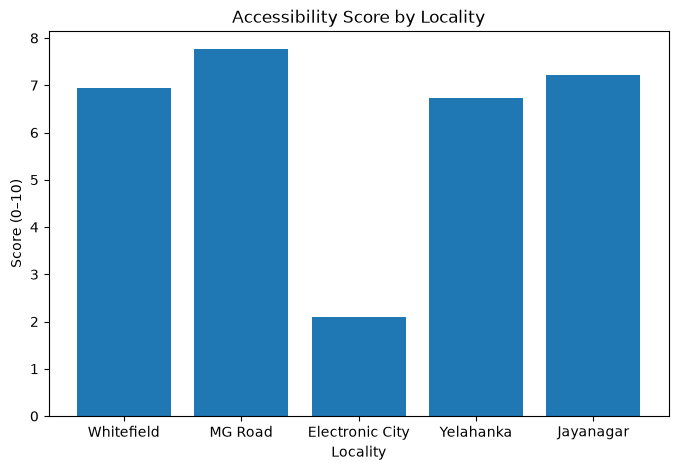

In [13]:
plt.figure(figsize=(8,5))

plt.bar(results_df['locality'], results_df['accessibility_score'])

plt.title('Accessibility Score by Locality')
plt.ylabel('Score (0–10)')
plt.xlabel('Locality')

plt.show()

In [14]:
results_df.to_csv(
    '../data/processed/bangalore_accessibility_scores.csv',
    index=False
)

print('Accessibility dataset saved successfully!')

Accessibility dataset saved successfully!


In [15]:
# ============================================================
# LOAD PROCESSED RENTAL DATA
# ============================================================

import pandas as pd

df = pd.read_csv(
    "../data/processed/rental_processed.csv"
)

print("Rental dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Rental dataset loaded successfully!
Shape: (7691, 5482)

Columns:
['locality', 'area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent', 'house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune', 'house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur', 'house_type_1 BHK Flat for Rent in Abhimaan Homes, Shirgaon, Pune', 'house_type_1 BHK Flat for Rent in Abhyudaya Nagar, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Aakansha I, Goregaon Mulund Link Road, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Harmony Chs Ltd, Andheri East, Mumbai', 'house_type_1 BHK Flat for Rent in Adarsh Nagar Lohegaon, Pune', 'house_type_1 BHK Flat for Rent in Adarsh Nagar, New Delhi', 'house_type_1 BHK Flat for Rent in Adithansh Apartment, Kondhwa, Pune', 'house_type_1 BHK Flat for Rent in Aditya Shagun, Bavdhan, Pune', 'house_type_1 BHK Flat for Rent in Aga Nagar, Vadgaonsheri, Pune', 'house_type_1 BHK Flat for Rent in Aishwarya Aangan, Chakan, Pune', 'house_type_1 BHK Flat for R

,locality,area,beds,bathrooms,balconies,area_rate,rent,"house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune","house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur","house_type_1 BHK Flat for Rent in Abhimaan Homes, Shirgaon, Pune",...,house_type_> 10 BHK Villa for Rent in Safdarjung Enclave New Delhi,city_Mumbai,city_Nagpur,city_New Delhi,city_Pune,furnishing_Semi-Furnished,furnishing_Unfurnished,area_per_bedroom,bath_per_bedroom,balcony_per_bedroom
0,Goregaon East,897.0,2,2,0,134.0,120000.0,False,False,False,...,False,True,False,False,False,True,False,448.5,1.0,0.0
1,Powai,490.0,1,1,0,82.0,40000.0,False,False,False,...,False,True,False,False,False,True,False,490.0,1.0,0.0
2,Mundhwa,550.0,1,1,0,22.0,12000.0,False,False,False,...,False,False,False,False,True,False,True,550.0,1.0,0.0
3,Hingna,1000.0,2,2,0,8.0,8000.0,False,False,False,...,False,False,True,False,False,False,True,500.0,1.0,0.0
4,Mira Road,595.0,1,1,0,25.0,15000.0,False,False,False,...,False,True,False,False,False,False,True,595.0,1.0,0.0


In [16]:
# ============================================================
# AREA RATE INVESTIGATION
# ============================================================

print("AREA RATE STATISTICS")
print("=" * 50)

print(df['area_rate'].describe())

AREA RATE STATISTICS
count    7691.000000
mean       47.619989
std        68.989657
min         2.000000
25%        21.000000
50%        31.000000
75%        54.000000
max      2586.000000
Name: area_rate, dtype: float64


In [17]:
print("\nSAMPLE PROPERTIES")
print("=" * 50)

print(
    df[['locality', 'city', 'area', 'beds', 'rent', 'area_rate']]
    .head(20)
)


SAMPLE PROPERTIES


KeyError: "['city'] not in index"

In [18]:
print("ALL COLUMNS IN DATASET")
print("=" * 50)

print(df.columns.tolist())

ALL COLUMNS IN DATASET
['locality', 'area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent', 'house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune', 'house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur', 'house_type_1 BHK Flat for Rent in Abhimaan Homes, Shirgaon, Pune', 'house_type_1 BHK Flat for Rent in Abhyudaya Nagar, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Aakansha I, Goregaon Mulund Link Road, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Harmony Chs Ltd, Andheri East, Mumbai', 'house_type_1 BHK Flat for Rent in Adarsh Nagar Lohegaon, Pune', 'house_type_1 BHK Flat for Rent in Adarsh Nagar, New Delhi', 'house_type_1 BHK Flat for Rent in Adithansh Apartment, Kondhwa, Pune', 'house_type_1 BHK Flat for Rent in Aditya Shagun, Bavdhan, Pune', 'house_type_1 BHK Flat for Rent in Aga Nagar, Vadgaonsheri, Pune', 'house_type_1 BHK Flat for Rent in Aishwarya Aangan, Chakan, Pune', 'house_type_1 BHK Flat for Rent in Ajmera Greenfinity, Wadala East, Mum

In [19]:
print("\nDATASET SHAPE:")
print(df.shape)

print("\nFIRST 5 ROWS:")
display(df.head())


DATASET SHAPE:
(7691, 5482)

FIRST 5 ROWS:


,locality,area,beds,bathrooms,balconies,area_rate,rent,"house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune","house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur","house_type_1 BHK Flat for Rent in Abhimaan Homes, Shirgaon, Pune",...,house_type_> 10 BHK Villa for Rent in Safdarjung Enclave New Delhi,city_Mumbai,city_Nagpur,city_New Delhi,city_Pune,furnishing_Semi-Furnished,furnishing_Unfurnished,area_per_bedroom,bath_per_bedroom,balcony_per_bedroom
0,Goregaon East,897.0,2,2,0,134.0,120000.0,False,False,False,...,False,True,False,False,False,True,False,448.5,1.0,0.0
1,Powai,490.0,1,1,0,82.0,40000.0,False,False,False,...,False,True,False,False,False,True,False,490.0,1.0,0.0
2,Mundhwa,550.0,1,1,0,22.0,12000.0,False,False,False,...,False,False,False,False,True,False,True,550.0,1.0,0.0
3,Hingna,1000.0,2,2,0,8.0,8000.0,False,False,False,...,False,False,True,False,False,False,True,500.0,1.0,0.0
4,Mira Road,595.0,1,1,0,25.0,15000.0,False,False,False,...,False,True,False,False,False,False,True,595.0,1.0,0.0


In [20]:
df['calculated_area_rate'] = df['rent'] / df['area']

print(
    df[
        ['locality', 'area', 'rent',
         'area_rate', 'calculated_area_rate']
    ].head(20)
)


                         locality    area      rent   area_rate  \
0                   Goregaon East   897.0  120000.0  134.000000   
1                           Powai   490.0   40000.0   82.000000   
2                         Mundhwa   550.0   12000.0   22.000000   
3                          Hingna  1000.0    8000.0    8.000000   
4                       Mira Road   595.0   15000.0   25.000000   
5                          Jakkur   600.0   16000.0   27.000000   
6               Chittaranjan Park  1260.0   60000.0   47.666667   
7               Soami Nagar South  2700.0  200000.0   74.111111   
8                        Hadapsar   650.0   11000.0   17.000000   
9                         Kharadi   495.0   24000.0   48.000000   
10                   Indira Nagar  2000.0   80000.0   40.000000   
11                     Whitefield  1543.0   60000.0   39.000000   
12                          Powai   380.0   70000.0  184.000000   
13                    Bandra East  1281.0  290000.0  222.00000

C:\Users\kopal\AppData\Local\Temp\ipykernel_4656\2748640891.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['calculated_area_rate'] = df['rent'] / df['area']


In [21]:
whitefield = df[
    df['locality']
    .astype(str)
    .str.lower()
    .str.contains('whitefield', na=False)
]

print("WHITEFIELD PROPERTIES")
print("=" * 50)

print(
    whitefield[
        ['locality', 'area', 'beds', 'bathrooms',
         'rent', 'area_rate']
    ].to_string(index=False)
)

print("\nWHITEFIELD STATISTICS")
print("=" * 50)

print("Number of properties:", len(whitefield))
print("Average rent:", whitefield['rent'].mean())
print("Median rent:", whitefield['rent'].median())
print("Average area rate:", whitefield['area_rate'].mean())
print("Median area rate:", whitefield['area_rate'].median())

WHITEFIELD PROPERTIES
                   locality   area  beds  bathrooms     rent  area_rate
                 Whitefield 1543.0     3          3  60000.0       39.0
                 Whitefield 1750.0     4          5 100000.0       57.0
                 Whitefield 1382.0     3          3 100000.0       72.0
                 Whitefield 1561.0     3          3  85000.0       54.0
    Upkar Layout Whitefield 5000.0     5          6 120000.0       24.0
                 Whitefield  550.0     1          1  26000.0       47.0
                 Whitefield  700.0     2          2  15000.0       21.0
                 Whitefield 1839.0     3          3  70000.0       38.0
                 Whitefield  680.0     1          1  60000.0       88.0
                 Whitefield 1655.0     3          3  50000.0       30.0
                 Whitefield 2600.0     4          4  85000.0       33.0
                 Whitefield 1346.0     2          2  55000.0       41.0
                 Whitefield 4550.0     5  

In [22]:
whitefield_2bhk = whitefield[whitefield['beds'] == 2]

print("WHITEFIELD 2 BHK PROPERTIES")
print("=" * 50)

print(
    whitefield_2bhk[
        ['area', 'beds', 'rent', 'area_rate']
    ].to_string(index=False)
)

print("\nStatistics:")
print("Median rent:", whitefield_2bhk['rent'].median())
print("Median area rate:", whitefield_2bhk['area_rate'].median())

WHITEFIELD 2 BHK PROPERTIES
  area  beds     rent  area_rate
 700.0     2  15000.0       21.0
1346.0     2  55000.0       41.0
1000.0     2  42000.0       42.0
1450.0     2  42000.0       29.0
 950.0     2  50000.0       53.0
1100.0     2  42000.0       38.0
1023.0     2  45000.0       44.0
 800.0     2  20000.0       25.0
 125.0     2  42000.0      336.0
1148.0     2 360000.0      314.0
1290.0     2  46000.0       36.0
1155.0     2  42000.0       36.0
1020.0     2  32000.0       31.0
 885.0     2  43000.0       49.0
1250.0     2  29000.0       23.0
1100.0     2  46000.0       42.0
 950.0     2 130000.0      132.0
1255.0     2  42000.0       33.0

Statistics:
Median rent: 42000.0
Median area rate: 39.5


In [23]:
print("AREA RATE OUTLIER CHECK")
print("=" * 50)

print("Total properties:", len(df))

print("\nArea rate statistics:")
print(df['area_rate'].describe())

print("\nProperties with area_rate > 100:")
high_rate = df[df['area_rate'] > 100]

print("Count:", len(high_rate))

print(
    high_rate[
        ['locality', 'area', 'beds', 'rent', 'area_rate']
    ]
    .sort_values('area_rate', ascending=False)
    .head(30)
    .to_string(index=False)
)

AREA RATE OUTLIER CHECK
Total properties: 7691

Area rate statistics:
count    7691.000000
mean       47.619989
std        68.989657
min         2.000000
25%        21.000000
50%        31.000000
75%        54.000000
max      2586.000000
Name: area_rate, dtype: float64

Properties with area_rate > 100:
Count: 704
            locality   area  beds      rent  area_rate
     Jogeshwari East  580.0     2 1500000.0     2586.0
       Jawahar Nagar  100.0     2  250000.0     2500.0
        Marathahalli    5.0     1   10500.0     2100.0
      Korba Mithagar  150.0     1  300000.0     2000.0
     Mukherjee Nagar 1450.0     1 1000000.0      690.0
              Bolinj  760.0     2  500000.0      658.0
               GK II    8.0     1    5000.0      625.0
  Panchsheel Enclave  216.0     3  130000.0      579.0
             Mundhwa   53.0     2   26000.0      491.0
     Sector 5 Rohini   52.0     2   25000.0      481.0
            KR Puram   30.0     2   14000.0      467.0
               Worli 3060

In [24]:
print("AREA RATE DISTRIBUTION")
print("=" * 50)

percentiles = df['area_rate'].quantile(
    [0.90, 0.95, 0.97, 0.98, 0.99, 0.995, 1.00]
)

for p, value in percentiles.items():
    print(f"{p*100:.1f}th percentile: {value:.2f}")

print("\nCounts above thresholds:")
for threshold in [75, 100, 150, 200, 300, 500]:
    count = (df['area_rate'] > threshold).sum()
    percentage = count / len(df) * 100
    print(
        f">{threshold:>3} ₹/sqft: "
        f"{count:>4} properties ({percentage:.2f}%)"
    )

AREA RATE DISTRIBUTION
90.0th percentile: 100.00
95.0th percentile: 133.00
97.0th percentile: 159.30
98.0th percentile: 185.20
99.0th percentile: 230.10
99.5th percentile: 275.00
100.0th percentile: 2586.00

Counts above thresholds:
> 75 ₹/sqft: 1230 properties (15.99%)
>100 ₹/sqft:  704 properties (9.15%)
>150 ₹/sqft:  266 properties (3.46%)
>200 ₹/sqft:  113 properties (1.47%)
>300 ₹/sqft:   32 properties (0.42%)
>500 ₹/sqft:    8 properties (0.10%)


In [25]:
# Remove extreme area_rate outliers
AREA_RATE_LIMIT = 300

df_clean = df[df['area_rate'] <= AREA_RATE_LIMIT].copy()

print("DATA CLEANING RESULTS")
print("=" * 50)

print("Original properties:", len(df))
print("Removed properties:", len(df) - len(df_clean))
print("Remaining properties:", len(df_clean))

print("\nArea rate after cleaning:")
print(df_clean['area_rate'].describe())

print("\nMaximum area rate:", df_clean['area_rate'].max())

DATA CLEANING RESULTS
Original properties: 7691
Removed properties: 32
Remaining properties: 7659

Area rate after cleaning:
count    7659.000000
mean       45.143143
std        39.875960
min         2.000000
25%        21.000000
50%        31.000000
75%        53.000000
max       300.000000
Name: area_rate, dtype: float64

Maximum area rate: 300.0


In [26]:
print("df_clean shape:", df_clean.shape)
print("df_clean columns:", df_clean.columns.tolist())

df_clean shape: (7659, 5483)
df_clean columns: ['locality', 'area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent', 'house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune', 'house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur', 'house_type_1 BHK Flat for Rent in Abhimaan Homes, Shirgaon, Pune', 'house_type_1 BHK Flat for Rent in Abhyudaya Nagar, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Aakansha I, Goregaon Mulund Link Road, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Harmony Chs Ltd, Andheri East, Mumbai', 'house_type_1 BHK Flat for Rent in Adarsh Nagar Lohegaon, Pune', 'house_type_1 BHK Flat for Rent in Adarsh Nagar, New Delhi', 'house_type_1 BHK Flat for Rent in Adithansh Apartment, Kondhwa, Pune', 'house_type_1 BHK Flat for Rent in Aditya Shagun, Bavdhan, Pune', 'house_type_1 BHK Flat for Rent in Aga Nagar, Vadgaonsheri, Pune', 'house_type_1 BHK Flat for Rent in Aishwarya Aangan, Chakan, Pune', 'house_type_1 BHK Flat for Rent in Ajmera Green

In [27]:
df_clean.to_csv(
    '../data/processed/trueestate_cleaned_7659.csv',
    index=False
)

print("✓ Cleaned dataset saved successfully")
print("Shape:", df_clean.shape)

✓ Cleaned dataset saved successfully
Shape: (7659, 5483)


In [26]:
print("CLEAN DATASET CHECK")
print("=" * 50)

print("Shape:", df_clean.shape)

print("\nColumns:")
print(df_clean.columns.tolist())

print("\nMissing values:")
print(df_clean.isnull().sum().sum())

print("\nData types:")
print(df_clean.dtypes.head(15))

CLEAN DATASET CHECK
Shape: (7659, 5483)

Columns:
['locality', 'area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent', 'house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune', 'house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur', 'house_type_1 BHK Flat for Rent in Abhimaan Homes, Shirgaon, Pune', 'house_type_1 BHK Flat for Rent in Abhyudaya Nagar, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Aakansha I, Goregaon Mulund Link Road, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Harmony Chs Ltd, Andheri East, Mumbai', 'house_type_1 BHK Flat for Rent in Adarsh Nagar Lohegaon, Pune', 'house_type_1 BHK Flat for Rent in Adarsh Nagar, New Delhi', 'house_type_1 BHK Flat for Rent in Adithansh Apartment, Kondhwa, Pune', 'house_type_1 BHK Flat for Rent in Aditya Shagun, Bavdhan, Pune', 'house_type_1 BHK Flat for Rent in Aga Nagar, Vadgaonsheri, Pune', 'house_type_1 BHK Flat for Rent in Aishwarya Aangan, Chakan, Pune', 'house_type_1 BHK Flat for Rent in Ajmera Gr

In [27]:
print("\nTARGET CHECK")
print("=" * 50)

print("Rent statistics:")
print(df_clean['rent'].describe())

print("\nSample:")
print(
    df_clean[
        ['locality', 'area', 'beds', 'bathrooms',
         'balconies', 'area_rate', 'rent']
    ].head(10).to_string(index=False)
)


TARGET CHECK
Rent statistics:
count    7.659000e+03
mean     5.272614e+04
std      8.614417e+04
min      1.000000e+03
25%      1.500000e+04
50%      2.800000e+04
75%      5.500000e+04
max      2.700000e+06
Name: rent, dtype: float64

Sample:
         locality   area  beds  bathrooms  balconies  area_rate     rent
    Goregaon East  897.0     2          2          0 134.000000 120000.0
            Powai  490.0     1          1          0  82.000000  40000.0
          Mundhwa  550.0     1          1          0  22.000000  12000.0
           Hingna 1000.0     2          2          0   8.000000   8000.0
        Mira Road  595.0     1          1          0  25.000000  15000.0
           Jakkur  600.0     1          1          0  27.000000  16000.0
Chittaranjan Park 1260.0     3          3          2  47.666667  60000.0
Soami Nagar South 2700.0     3          3          2  74.111111 200000.0
         Hadapsar  650.0     1          1          0  17.000000  11000.0
          Kharadi  495.0   

In [28]:
print("DF_CLEAN STRUCTURE")
print("=" * 50)

print("Shape:", df_clean.shape)

print("\nFirst 20 columns:")
print(df_clean.columns[:20].tolist())

print("\nLast 20 columns:")
print(df_clean.columns[-20:].tolist())

print("\nTarget present:", 'rent' in df_clean.columns)

print("\nObject columns:")
print(df_clean.select_dtypes(include='object').columns.tolist())

print("\nNumeric columns:", len(df_clean.select_dtypes(include='number').columns))

DF_CLEAN STRUCTURE
Shape: (7659, 5483)

First 20 columns:
['locality', 'area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent', 'house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune', 'house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur', 'house_type_1 BHK Flat for Rent in Abhimaan Homes, Shirgaon, Pune', 'house_type_1 BHK Flat for Rent in Abhyudaya Nagar, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Aakansha I, Goregaon Mulund Link Road, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Harmony Chs Ltd, Andheri East, Mumbai', 'house_type_1 BHK Flat for Rent in Adarsh Nagar Lohegaon, Pune', 'house_type_1 BHK Flat for Rent in Adarsh Nagar, New Delhi', 'house_type_1 BHK Flat for Rent in Adithansh Apartment, Kondhwa, Pune', 'house_type_1 BHK Flat for Rent in Aditya Shagun, Bavdhan, Pune', 'house_type_1 BHK Flat for Rent in Aga Nagar, Vadgaonsheri, Pune', 'house_type_1 BHK Flat for Rent in Aishwarya Aangan, Chakan, Pune', 'house_type_1 BHK Flat for Rent in A

C:\Users\kopal\AppData\Local\Temp\ipykernel_16640\3259724074.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_clean.select_dtypes(include='object').columns.tolist())


['locality']

Numeric columns: 10


In [29]:
print("RAW + ENGINEERED COLUMNS")
print("=" * 50)

for i, col in enumerate(df_clean.columns[:15]):
    print(i, ":", col)

print("\nTOTAL COLUMNS:", len(df_clean.columns))

print("\nLAST 15 COLUMNS")
for i, col in enumerate(df_clean.columns[-15:], start=len(df_clean.columns)-15):
    print(i, ":", col)

RAW + ENGINEERED COLUMNS
0 : locality
1 : area
2 : beds
3 : bathrooms
4 : balconies
5 : area_rate
6 : rent
7 : house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune
8 : house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur
9 : house_type_1 BHK Flat for Rent in Abhimaan Homes, Shirgaon, Pune
10 : house_type_1 BHK Flat for Rent in Abhyudaya Nagar, Mumbai
11 : house_type_1 BHK Flat for Rent in Acme Aakansha I, Goregaon Mulund Link Road, Mumbai
12 : house_type_1 BHK Flat for Rent in Acme Harmony Chs Ltd, Andheri East, Mumbai
13 : house_type_1 BHK Flat for Rent in Adarsh Nagar Lohegaon, Pune
14 : house_type_1 BHK Flat for Rent in Adarsh Nagar, New Delhi

TOTAL COLUMNS: 5483

LAST 15 COLUMNS
5468 : house_type_> 10 BHK Flat for Rent in Lakkasandra Extension, Wilson Garden, Bangalore
5469 : house_type_> 10 BHK House for Rent in Dwarka New Delhi
5470 : house_type_> 10 BHK House for Rent in Greater Kailash Enclave 1 New Delhi
5471 : house_type_> 10 BHK House for Rent in Lonik

In [30]:
print("CURRENT MODEL DATA CHECK")
print("=" * 50)

print("df_clean shape:", df_clean.shape)

print("\nColumns if locality + rent are removed:")
print(
    df_clean.drop(columns=['locality', 'rent']).shape
)

print("\nColumns if only rent is removed:")
print(
    df_clean.drop(columns=['rent']).shape
)

CURRENT MODEL DATA CHECK
df_clean shape: (7659, 5483)

Columns if locality + rent are removed:
(7659, 5481)

Columns if only rent is removed:
(7659, 5482)


In [31]:
print("ORIGINAL TRAINING DATA")
print("=" * 50)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

ORIGINAL TRAINING DATA


NameError: name 'X_train' is not defined

In [32]:
print("CALCULATED AREA RATE CHECK")
print("=" * 50)

print(
    df_clean[
        ['area', 'rent', 'area_rate', 'calculated_area_rate']
    ].head(10).to_string(index=False)
)

print("\nCorrelation with rent:")
print(
    df_clean[
        ['area_rate', 'calculated_area_rate', 'rent']
    ].corr()['rent']
)

CALCULATED AREA RATE CHECK
  area     rent  area_rate  calculated_area_rate
 897.0 120000.0 134.000000            133.779264
 490.0  40000.0  82.000000             81.632653
 550.0  12000.0  22.000000             21.818182
1000.0   8000.0   8.000000              8.000000
 595.0  15000.0  25.000000             25.210084
 600.0  16000.0  27.000000             26.666667
1260.0  60000.0  47.666667             47.619048
2700.0 200000.0  74.111111             74.074074
 650.0  11000.0  17.000000             16.923077
 495.0  24000.0  48.000000             48.484848

Correlation with rent:
area_rate               0.635937
calculated_area_rate    0.092942
rent                    1.000000
Name: rent, dtype: float64


In [33]:
print("\nLEAKAGE CHECK")
print("=" * 50)

calculated = df_clean['rent'] / df_clean['area']

print(
    "Matches rent / area:",
    (df_clean['calculated_area_rate'].round(6) == calculated.round(6)).mean()
)


LEAKAGE CHECK
Matches rent / area: 1.0


In [34]:
X = df_clean.drop(
    columns=['locality', 'rent', 'calculated_area_rate']
)

y = df_clean['rent']

In [35]:
print("PREPARING CLEAN MODEL DATA")
print("=" * 50)

# Remove non-predictive / leakage columns
X = df_clean.drop(
    columns=['locality', 'rent', 'calculated_area_rate']
)

# Target
y = df_clean['rent']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nRemaining object columns:")
print(X.select_dtypes(include='object').columns.tolist())

print("\nTarget statistics:")
print(y.describe())

PREPARING CLEAN MODEL DATA
X shape: (7659, 5480)
y shape: (7659,)

Remaining object columns:
[]

Target statistics:
count    7.659000e+03
mean     5.272614e+04
std      8.614417e+04
min      1.000000e+03
25%      1.500000e+04
50%      2.800000e+04
75%      5.500000e+04
max      2.700000e+06
Name: rent, dtype: float64


In [36]:
from sklearn.model_selection import train_test_split

print("TRAIN / TEST SPLIT")
print("=" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Features:", X_train.shape[1])

TRAIN / TEST SPLIT
Training samples: 6127
Testing samples: 1532
Features: 5480


In [37]:
from xgboost import XGBRegressor

print("TRAINING CLEAN XGBOOST MODEL")
print("=" * 50)

xgb_clean = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_clean.fit(X_train, y_train)

print("\nTraining completed successfully!")

TRAINING CLEAN XGBOOST MODEL

Training completed successfully!


In [38]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("CLEAN XGBOOST EVALUATION")
print("=" * 50)

# Predictions
y_pred = xgb_clean.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score : {r2:.6f}")
print(f"RMSE     : ₹{rmse:,.2f}")
print(f"MAE      : ₹{mae:,.2f}")

CLEAN XGBOOST EVALUATION
R² Score : 0.973346
RMSE     : ₹13,029.35
MAE      : ₹2,912.08


In [39]:
print("\nSAMPLE PREDICTIONS")
print("=" * 50)

comparison = X_test.copy()

comparison["Actual Rent"] = y_test
comparison["Predicted Rent"] = y_pred
comparison["Difference"] = comparison["Predicted Rent"] - comparison["Actual Rent"]

print(
    comparison[
        ["Actual Rent", "Predicted Rent", "Difference"]
    ].head(10).to_string(index=False)
)


SAMPLE PREDICTIONS
 Actual Rent  Predicted Rent   Difference
     31000.0    32096.271484  1096.271484
    100000.0   103534.218750  3534.218750
     12000.0    11838.959961  -161.040039
     78000.0    77880.710938  -119.289062
     27500.0    29237.042969  1737.042969
     18000.0    19382.091797  1382.091797
     10000.0    11314.038086  1314.038086
     25000.0    25078.097656    78.097656
    330000.0   349276.500000 19276.500000
     42000.0    42680.281250   680.281250


In [40]:
print("RENT RANGE PERFORMANCE")
print("=" * 60)

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

results['Error'] = results['Predicted'] - results['Actual']
results['Absolute_Error'] = abs(results['Error'])

ranges = [
    ("Low Rent (< ₹20K)", results['Actual'] < 20000),
    ("Mid Rent (₹20K–₹50K)",
     (results['Actual'] >= 20000) & (results['Actual'] < 50000)),
    ("High Rent (₹50K–₹1L)",
     (results['Actual'] >= 50000) & (results['Actual'] < 100000)),
    ("Very High Rent (> ₹1L)", results['Actual'] >= 100000)
]

for name, condition in ranges:
    subset = results[condition]

    print(f"\n{name}")
    print("-" * 40)
    print("Properties:", len(subset))
    print("MAE: ₹{:,.2f}".format(subset['Absolute_Error'].mean()))
    print("RMSE: ₹{:,.2f}".format(
        np.sqrt((subset['Error'] ** 2).mean())
    ))

RENT RANGE PERFORMANCE

Low Rent (< ₹20K)
----------------------------------------
Properties: 491
MAE: ₹1,094.69
RMSE: ₹5,209.44

Mid Rent (₹20K–₹50K)
----------------------------------------
Properties: 568
MAE: ₹1,174.99
RMSE: ₹4,605.83

High Rent (₹50K–₹1L)
----------------------------------------
Properties: 295
MAE: ₹2,364.78
RMSE: ₹4,680.80

Very High Rent (> ₹1L)
----------------------------------------
Properties: 178
MAE: ₹14,375.35
RMSE: ₹35,808.55


In [41]:
print("TOP FEATURE IMPORTANCE")
print("=" * 60)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_clean.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(20).to_string(index=False))

TOP FEATURE IMPORTANCE
                                                                   Feature  Importance
                                                               city_Mumbai    0.177485
                                                                 bathrooms    0.174764
                                                                      area    0.162556
                                                                 area_rate    0.142864
house_type_3 BHK Flat for Rent in Lokhandwala Minerva, Mahalakshmi, Mumbai    0.076582
                                                                      beds    0.065759
                                                          area_per_bedroom    0.035665
                   house_type_4 BHK Villa for Rent in Whitefield Bangalore    0.032012
                                                                 balconies    0.016393
                    house_type_3 BHK Flat for Rent in Andheri West, Mumbai    0.013517
                    

In [42]:
print("ACCESSIBILITY FEATURES")
print("=" * 60)

accessibility_cols = [
    col for col in X.columns
    if any(keyword in col.lower()
           for keyword in [
               'hospital',
               'school',
               'mall',
               'metro',
               'accessibility'
           ])
]

print("Number of accessibility features:", len(accessibility_cols))

print("\nFeatures found:")
for col in accessibility_cols:
    print(col)

ACCESSIBILITY FEATURES
Number of accessibility features: 26

Features found:
house_type_1 BHK Flat for Rent in Hind Rajasthan Apartment, Sion Hospital Colony, Mumbai
house_type_1 BHK Flat for Rent in Malleshpalya Main Road, Bangalore
house_type_1 BHK Flat for Rent in Malleshwaram, Bangalore
house_type_1 BHK Flat for Rent in Mega Mall, Oshiwara, Mumbai
house_type_1 BHK House for Rent in Mall Road New Delhi
house_type_1 BHK House for Rent in Vyalikaval, Malleshwaram Bangalore
house_type_2 BHK Flat for Rent in Elite Metro Jazz, Mahalunge, Pune
house_type_2 BHK Flat for Rent in Ensaara Metropark, Pipla, Nagpur
house_type_2 BHK Flat for Rent in MGF Metropolitan Mall Saket, Block J Saket, New Delhi
house_type_2 BHK Flat for Rent in Malleshpalya Main Road, Bangalore
house_type_2 BHK Flat for Rent in Malleshpalya, Kaggadasapura, Bangalore
house_type_2 BHK Flat for Rent in Metro Greens, Tilekar Nagar, Kondhwa Budruk, Pune
house_type_2 BHK Flat for Rent in Metro Jazz, Baner, Pune
house_type_2 BH

In [43]:
print("ACTUAL ACCESSIBILITY FEATURES")
print("=" * 60)

accessibility_cols = [
    col for col in X.columns
    if not col.startswith("house_type_")
    and any(keyword in col.lower()
            for keyword in [
                'hospital',
                'school',
                'mall',
                'metro',
                'accessibility'
            ])
]

print("Number of actual accessibility features:", len(accessibility_cols))

if accessibility_cols:
    print("\nFeatures found:")
    for col in accessibility_cols:
        print("-", col)
else:
    print("\nNo actual accessibility features found.")

ACTUAL ACCESSIBILITY FEATURES
Number of actual accessibility features: 0

No actual accessibility features found.


In [44]:
print("\nNON-HOUSE-TYPE LOCATION FEATURES")
print("=" * 60)

for col in X.columns:
    if not col.startswith("house_type_"):
        print(col)


NON-HOUSE-TYPE LOCATION FEATURES
area
beds
bathrooms
balconies
area_rate
city_Mumbai
city_Nagpur
city_New Delhi
city_Pune
furnishing_Semi-Furnished
furnishing_Unfurnished
area_per_bedroom
bath_per_bedroom
balcony_per_bedroom


In [45]:
print("ACCESSIBILITY DATAFRAMES")
print("=" * 60)

for name, obj in globals().items():
    try:
        if isinstance(obj, pd.DataFrame):
            cols = obj.columns.tolist()

            if any(
                col in cols
                for col in [
                    'hospital_km',
                    'school_km',
                    'mall_km',
                    'metro_km',
                    'accessibility_score'
                ]
            ):
                print("\nDataFrame:", name)
                print("Shape:", obj.shape)
                print("Columns:", cols)
    except:
        pass

ACCESSIBILITY DATAFRAMES


RuntimeError: dictionary changed size during iteration

In [46]:
print("ACCESSIBILITY DATAFRAMES")
print("=" * 60)

for name in list(globals().keys()):
    try:
        obj = globals()[name]

        if isinstance(obj, pd.DataFrame):
            cols = obj.columns.tolist()

            if any(
                col in cols
                for col in [
                    'hospital_km',
                    'school_km',
                    'mall_km',
                    'metro_km',
                    'accessibility_score'
                ]
            ):
                print("\nDataFrame:", name)
                print("Shape:", obj.shape)
                print("Columns:", cols)

    except Exception:
        pass

ACCESSIBILITY DATAFRAMES

DataFrame: results_df
Shape: (5, 6)
Columns: ['locality', 'hospital_km', 'school_km', 'mall_km', 'metro_km', 'accessibility_score']


In [47]:
print("ACCESSIBILITY DATA")
print("=" * 60)

print(results_df.to_string(index=False))

ACCESSIBILITY DATA
       locality  hospital_km  school_km  mall_km  metro_km  accessibility_score
     Whitefield         0.11       0.09     0.05      1.79                 6.94
        MG Road         0.79       0.37     0.07      0.14                 7.76
Electronic City         3.90       3.22     6.51      3.38                 2.10
      Yelahanka         0.08       0.73     0.72      0.68                 6.73
      Jayanagar         0.06       0.04     0.51      1.06                 7.21


In [48]:
print("\nLOCALITY COVERAGE")
print("=" * 60)

print("Unique localities in property data:", df_clean['locality'].nunique())
print("Unique localities with accessibility data:", results_df['locality'].nunique())

print("\nAccessibility localities:")
print(results_df['locality'].tolist())


LOCALITY COVERAGE
Unique localities in property data: 1978
Unique localities with accessibility data: 5

Accessibility localities:
['Whitefield', 'MG Road', 'Electronic City', 'Yelahanka', 'Jayanagar']


In [49]:
print("OSM / LOCATION DATAFRAMES")
print("=" * 60)

for name in list(globals().keys()):
    try:
        obj = globals()[name]

        if isinstance(obj, pd.DataFrame):
            cols = set(obj.columns)

            location_keywords = {
                'lat', 'lon', 'latitude', 'longitude',
                'amenity', 'name', 'type'
            }

            if len(cols.intersection(location_keywords)) >= 2:
                print(f"\n{name}")
                print("Shape:", obj.shape)
                print("Columns:", obj.columns.tolist())

    except Exception:
        pass

OSM / LOCATION DATAFRAMES

hospitals
Shape: (1073, 4)
Columns: ['name', 'category', 'latitude', 'longitude']

schools
Shape: (1459, 4)
Columns: ['name', 'category', 'latitude', 'longitude']

malls
Shape: (74, 4)
Columns: ['name', 'category', 'latitude', 'longitude']

metro
Shape: (94, 3)
Columns: ['name', 'latitude', 'longitude']


In [50]:
print("LOCALITY COORDINATE DATA")
print("=" * 60)

for name in list(globals().keys()):
    try:
        obj = globals()[name]

        if isinstance(obj, pd.DataFrame):
            cols = set(obj.columns)

            if (
                'locality' in cols
                and (
                    ('latitude' in cols and 'longitude' in cols)
                    or ('lat' in cols and 'lon' in cols)
                )
            ):
                print(f"\nDataFrame: {name}")
                print("Shape:", obj.shape)
                print("Columns:", obj.columns.tolist())

    except Exception:
        pass

LOCALITY COORDINATE DATA


In [51]:
print("LOCALITY + CITY COVERAGE")
print("=" * 60)

locality_city = (
    df_clean[['locality', 'city']]
    .drop_duplicates()
    .sort_values(['city', 'locality'])
)

print("Unique locality-city combinations:", len(locality_city))

print("\nLocalities by city:")
print(
    locality_city.groupby('city')['locality']
    .nunique()
    .sort_values(ascending=False)
)

LOCALITY + CITY COVERAGE


KeyError: "['city'] not in index"

In [52]:
print("DATAFRAMES WITH LOCALITY + CITY")
print("=" * 60)

for name in list(globals().keys()):
    try:
        obj = globals()[name]

        if isinstance(obj, pd.DataFrame):
            cols = set(obj.columns)

            if 'locality' in cols and 'city' in cols:
                print(f"\nDataFrame: {name}")
                print("Shape:", obj.shape)
                print("Columns:", obj.columns.tolist())

    except Exception:
        pass

DATAFRAMES WITH LOCALITY + CITY


In [53]:
print("RECONSTRUCTING CITY")
print("=" * 60)

df_location = df_clean[['locality']].copy()

df_location['city'] = 'Bangalore'

df_location.loc[
    df_clean['city_Mumbai'] == 1,
    'city'
] = 'Mumbai'

df_location.loc[
    df_clean['city_Nagpur'] == 1,
    'city'
] = 'Nagpur'

df_location.loc[
    df_clean['city_New Delhi'] == 1,
    'city'
] = 'New Delhi'

df_location.loc[
    df_clean['city_Pune'] == 1,
    'city'
] = 'Pune'

print("Unique cities:")
print(df_location['city'].value_counts())

print("\nUnique locality-city combinations:",
      df_location.drop_duplicates().shape[0])

print("\nSample:")
print(
    df_location.drop_duplicates()
    .head(30)
    .to_string(index=False)
)

RECONSTRUCTING CITY
Unique cities:
city
New Delhi    1799
Bangalore    1786
Pune         1778
Mumbai       1701
Nagpur        595
Name: count, dtype: int64

Unique locality-city combinations: 2000

Sample:
                     locality      city
                Goregaon East    Mumbai
                        Powai    Mumbai
                      Mundhwa      Pune
                       Hingna    Nagpur
                    Mira Road    Mumbai
                       Jakkur Bangalore
            Chittaranjan Park New Delhi
            Soami Nagar South New Delhi
                     Hadapsar      Pune
                      Kharadi      Pune
                 Indira Nagar Bangalore
                   Whitefield Bangalore
                  Bandra East    Mumbai
Jogeshwari Vikhroli Link Road    Mumbai
                    Hinjewadi      Pune
             Jyoti Nagar East New Delhi
      Madanpur Khadar Village New Delhi
              C V Raman Nagar Bangalore
                        Baner     

In [54]:
print("CITY DISTRIBUTION")
print("=" * 60)

city_counts = df_clean['city'].value_counts()

print(city_counts)
print("\nTotal properties:", city_counts.sum())
print("Unique cities:", df_clean['city'].nunique())

CITY DISTRIBUTION


KeyError: 'city'

In [55]:
print("ACTUAL COLUMNS IN df_clean")
print("=" * 50)

print(df_clean.columns.tolist())

ACTUAL COLUMNS IN df_clean
['locality', 'area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent', 'house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune', 'house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur', 'house_type_1 BHK Flat for Rent in Abhimaan Homes, Shirgaon, Pune', 'house_type_1 BHK Flat for Rent in Abhyudaya Nagar, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Aakansha I, Goregaon Mulund Link Road, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Harmony Chs Ltd, Andheri East, Mumbai', 'house_type_1 BHK Flat for Rent in Adarsh Nagar Lohegaon, Pune', 'house_type_1 BHK Flat for Rent in Adarsh Nagar, New Delhi', 'house_type_1 BHK Flat for Rent in Adithansh Apartment, Kondhwa, Pune', 'house_type_1 BHK Flat for Rent in Aditya Shagun, Bavdhan, Pune', 'house_type_1 BHK Flat for Rent in Aga Nagar, Vadgaonsheri, Pune', 'house_type_1 BHK Flat for Rent in Aishwarya Aangan, Chakan, Pune', 'house_type_1 BHK Flat for Rent in Ajmera Greenfinity, Wadala East,

In [56]:
print(df_clean.columns.tolist())

['locality', 'area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent', 'house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune', 'house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur', 'house_type_1 BHK Flat for Rent in Abhimaan Homes, Shirgaon, Pune', 'house_type_1 BHK Flat for Rent in Abhyudaya Nagar, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Aakansha I, Goregaon Mulund Link Road, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Harmony Chs Ltd, Andheri East, Mumbai', 'house_type_1 BHK Flat for Rent in Adarsh Nagar Lohegaon, Pune', 'house_type_1 BHK Flat for Rent in Adarsh Nagar, New Delhi', 'house_type_1 BHK Flat for Rent in Adithansh Apartment, Kondhwa, Pune', 'house_type_1 BHK Flat for Rent in Aditya Shagun, Bavdhan, Pune', 'house_type_1 BHK Flat for Rent in Aga Nagar, Vadgaonsheri, Pune', 'house_type_1 BHK Flat for Rent in Aishwarya Aangan, Chakan, Pune', 'house_type_1 BHK Flat for Rent in Ajmera Greenfinity, Wadala East, Mumbai', 'house_type_1 BHK

In [57]:
print("=" * 70)
print("DF_CLEAN COLUMN STRUCTURE")
print("=" * 70)

for i, col in enumerate(df_clean.columns):
    print(f"{i:3} -> {col}")

DF_CLEAN COLUMN STRUCTURE
  0 -> locality
  1 -> area
  2 -> beds
  3 -> bathrooms
  4 -> balconies
  5 -> area_rate
  6 -> rent
  7 -> house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune
  8 -> house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur
  9 -> house_type_1 BHK Flat for Rent in Abhimaan Homes, Shirgaon, Pune
 10 -> house_type_1 BHK Flat for Rent in Abhyudaya Nagar, Mumbai
 11 -> house_type_1 BHK Flat for Rent in Acme Aakansha I, Goregaon Mulund Link Road, Mumbai
 12 -> house_type_1 BHK Flat for Rent in Acme Harmony Chs Ltd, Andheri East, Mumbai
 13 -> house_type_1 BHK Flat for Rent in Adarsh Nagar Lohegaon, Pune
 14 -> house_type_1 BHK Flat for Rent in Adarsh Nagar, New Delhi
 15 -> house_type_1 BHK Flat for Rent in Adithansh Apartment, Kondhwa, Pune
 16 -> house_type_1 BHK Flat for Rent in Aditya Shagun, Bavdhan, Pune
 17 -> house_type_1 BHK Flat for Rent in Aga Nagar, Vadgaonsheri, Pune
 18 -> house_type_1 BHK Flat for Rent in Aishwarya Aangan, Chakan

In [58]:
print("house_type" in df.columns)
print(df.columns.tolist())

False
['locality', 'area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent', 'house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune', 'house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur', 'house_type_1 BHK Flat for Rent in Abhimaan Homes, Shirgaon, Pune', 'house_type_1 BHK Flat for Rent in Abhyudaya Nagar, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Aakansha I, Goregaon Mulund Link Road, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Harmony Chs Ltd, Andheri East, Mumbai', 'house_type_1 BHK Flat for Rent in Adarsh Nagar Lohegaon, Pune', 'house_type_1 BHK Flat for Rent in Adarsh Nagar, New Delhi', 'house_type_1 BHK Flat for Rent in Adithansh Apartment, Kondhwa, Pune', 'house_type_1 BHK Flat for Rent in Aditya Shagun, Bavdhan, Pune', 'house_type_1 BHK Flat for Rent in Aga Nagar, Vadgaonsheri, Pune', 'house_type_1 BHK Flat for Rent in Aishwarya Aangan, Chakan, Pune', 'house_type_1 BHK Flat for Rent in Ajmera Greenfinity, Wadala East, Mumbai', 'house_type

In [59]:
print("house_type" in df_clean.columns)

False


In [60]:
import re

# Get all one-hot encoded house_type columns
house_type_cols = [
    col for col in df_clean.columns
    if col.startswith("house_type_")
]

print("Number of house_type columns:", len(house_type_cols))

print("\nFirst 10 house_type columns:")
for col in house_type_cols[:10]:
    print(col)

Number of house_type columns: 5466

First 10 house_type columns:
house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune
house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur
house_type_1 BHK Flat for Rent in Abhimaan Homes, Shirgaon, Pune
house_type_1 BHK Flat for Rent in Abhyudaya Nagar, Mumbai
house_type_1 BHK Flat for Rent in Acme Aakansha I, Goregaon Mulund Link Road, Mumbai
house_type_1 BHK Flat for Rent in Acme Harmony Chs Ltd, Andheri East, Mumbai
house_type_1 BHK Flat for Rent in Adarsh Nagar Lohegaon, Pune
house_type_1 BHK Flat for Rent in Adarsh Nagar, New Delhi
house_type_1 BHK Flat for Rent in Adithansh Apartment, Kondhwa, Pune
house_type_1 BHK Flat for Rent in Aditya Shagun, Bavdhan, Pune


In [61]:
print("\nLast 10 house_type columns:")
for col in house_type_cols[-10:]:
    print(col)


Last 10 house_type columns:
house_type_8 BHK Flat for Rent in Sukhdev Vihar, Okhla, New Delhi
house_type_8 BHK House for Rent in Hoskote Bangalore
house_type_8 BHK Villa for Rent in Kundalahalli, Brookefield Bangalore
house_type_8 BHK Villa for Rent in Sadahalli Main Road Bangalore
house_type_> 10 BHK Flat for Rent in Bagalur Main Road, Bangalore
house_type_> 10 BHK Flat for Rent in Lakkasandra Extension, Wilson Garden, Bangalore
house_type_> 10 BHK House for Rent in Dwarka New Delhi
house_type_> 10 BHK House for Rent in Greater Kailash Enclave 1 New Delhi
house_type_> 10 BHK House for Rent in Lonikand Pune
house_type_> 10 BHK Villa for Rent in Safdarjung Enclave New Delhi


In [62]:
cities_found = set()

for col in house_type_cols:
    if ", Pune" in col:
        cities_found.add("Pune")
    elif ", Mumbai" in col:
        cities_found.add("Mumbai")
    elif ", Bangalore" in col:
        cities_found.add("Bangalore")
    elif ", New Delhi" in col:
        cities_found.add("New Delhi")
    elif ", Nagpur" in col:
        cities_found.add("Nagpur")

print("Cities found in house_type columns:")
print(sorted(cities_found))

Cities found in house_type columns:
['Bangalore', 'Mumbai', 'Nagpur', 'New Delhi', 'Pune']


In [63]:
import numpy as np

# Get all house_type one-hot columns
house_type_cols = [
    col for col in df_clean.columns
    if col.startswith("house_type_")
]

# Create an empty city column
df_clean['city'] = np.nan

# Assign city based on the active house_type column
for city in ['Pune', 'Mumbai', 'Bangalore', 'New Delhi', 'Nagpur']:
    
    city_cols = [
        col for col in house_type_cols
        if col.endswith(f", {city}")
    ]
    
    if not city_cols:
        print(f"⚠️ No columns found for {city}")
        continue
    
    # Rows where ANY house_type column for this city is active
    city_mask = df_clean[city_cols].sum(axis=1) > 0
    
    df_clean.loc[city_mask, 'city'] = city

print("City reconstruction complete.")

TypeError: Invalid value 'Pune' for dtype 'float64'

In [64]:
# Remove the incorrectly created city column
if 'city' in df_clean.columns:
    df_clean = df_clean.drop(columns=['city'])

# Create city as a string/object column
df_clean['city'] = None

# Get all one-hot encoded house_type columns
house_type_cols = [
    col for col in df_clean.columns
    if col.startswith("house_type_")
]

# Reconstruct city
cities = ['Pune', 'Mumbai', 'Bangalore', 'New Delhi', 'Nagpur']

for city in cities:

    city_cols = [
        col for col in house_type_cols
        if col.endswith(f", {city}")
    ]

    city_mask = df_clean[city_cols].sum(axis=1) > 0

    df_clean.loc[city_mask, 'city'] = city

print("City reconstruction complete.")

City reconstruction complete.


In [65]:
print("=" * 60)
print("RECONSTRUCTED CITY DISTRIBUTION")
print("=" * 60)

print(df_clean['city'].value_counts(dropna=False))

print("\nTotal properties:", len(df_clean))
print("Missing city:", df_clean['city'].isna().sum())
print("Unique cities:", df_clean['city'].nunique())

RECONSTRUCTED CITY DISTRIBUTION
city
None         1790
Mumbai       1593
Pune         1480
New Delhi    1307
Bangalore    1103
Nagpur        386
Name: count, dtype: int64

Total properties: 7659
Missing city: 1790
Unique cities: 5


In [66]:
df_clean = df_clean.drop(columns=['city'])

In [67]:
print("=" * 70)
print("CHECKING AVAILABLE DATAFRAME VARIABLES")
print("=" * 70)

for name, obj in globals().items():
    if hasattr(obj, 'shape') and hasattr(obj, 'columns'):
        print(f"{name:25} shape={obj.shape}")

CHECKING AVAILABLE DATAFRAME VARIABLES
hospitals                 shape=(1073, 4)
schools                   shape=(1459, 4)
malls                     shape=(74, 4)
metro                     shape=(94, 3)
results                   shape=(1532, 4)
results_df                shape=(5, 6)
df                        shape=(7691, 5483)
whitefield                shape=(90, 5483)
whitefield_2bhk           shape=(18, 5483)
high_rate                 shape=(704, 5483)
df_clean                  shape=(7659, 5483)
X                         shape=(7659, 5480)
X_train                   shape=(6127, 5480)
X_test                    shape=(1532, 5480)
comparison                shape=(1532, 5483)
subset                    shape=(178, 4)
importance                shape=(5480, 2)
df_location               shape=(7659, 2)


In [68]:
print("=" * 60)
print("DF_LOCATION")
print("=" * 60)

print(df_location.columns.tolist())

print("\nShape:", df_location.shape)

display(df_location.head(20))

DF_LOCATION
['locality', 'city']

Shape: (7659, 2)


,locality,city
0,Goregaon East,Mumbai
1,Powai,Mumbai
2,Mundhwa,Pune
3,Hingna,Nagpur
4,Mira Road,Mumbai
5,Jakkur,Bangalore
6,Chittaranjan Park,New Delhi
7,Soami Nagar South,New Delhi
8,Hadapsar,Pune
9,Kharadi,Pune


In [69]:
print("=" * 60)
print("DF_LOCATION CITY DISTRIBUTION")
print("=" * 60)

print(df_location.iloc[:, 1].value_counts(dropna=False))

DF_LOCATION CITY DISTRIBUTION
city
New Delhi    1799
Bangalore    1786
Pune         1778
Mumbai       1701
Nagpur        595
Name: count, dtype: int64


In [70]:
print("=" * 60)
print("DF_LOCATION COLUMNS")
print("=" * 60)

print(df_location.columns.tolist())

print("\nShape:", df_location.shape)

display(df_location.head(20))

DF_LOCATION COLUMNS
['locality', 'city']

Shape: (7659, 2)


,locality,city
0,Goregaon East,Mumbai
1,Powai,Mumbai
2,Mundhwa,Pune
3,Hingna,Nagpur
4,Mira Road,Mumbai
5,Jakkur,Bangalore
6,Chittaranjan Park,New Delhi
7,Soami Nagar South,New Delhi
8,Hadapsar,Pune
9,Kharadi,Pune


In [71]:
print("=" * 60)
print("DF_LOCATION VALIDATION")
print("=" * 60)

print("Missing locality:", df_location['locality'].isna().sum())
print("Missing city:", df_location['city'].isna().sum())

print("\nUnique cities:", df_location['city'].nunique())
print("Unique localities:", df_location['locality'].nunique())

DF_LOCATION VALIDATION
Missing locality: 0
Missing city: 0

Unique cities: 5
Unique localities: 1978


In [72]:
locality_city = (
    df_location[['locality', 'city']]
    .drop_duplicates()
    .sort_values(['city', 'locality'])
)

print("=" * 60)
print("LOCALITY + CITY COVERAGE")
print("=" * 60)

print("Unique locality-city combinations:", len(locality_city))

display(locality_city.head(30))

LOCALITY + CITY COVERAGE
Unique locality-city combinations: 2000


,locality,city
230,1A Block Koramangala,Bangalore
2906,1st Block East,Bangalore
7050,A Narayanapura,Bangalore
3574,AECS Layout Block A,Bangalore
5043,AECS Layout Block D,Bangalore
7455,AECS Layout-Singasandra,Bangalore
5851,AK Colony Domlur,Bangalore
6643,AMS Layout,Bangalore
1233,Abbaiah Reddy Layout,Bangalore
363,Abbigere,Bangalore


In [73]:
locality_city_counts = (
    df_location
    .groupby('locality')['city']
    .nunique()
    .sort_values(ascending=False)
)

ambiguous_localities = locality_city_counts[
    locality_city_counts > 1
]

print("=" * 60)
print("LOCALITIES MAPPED TO MULTIPLE CITIES")
print("=" * 60)

print("Ambiguous localities:", len(ambiguous_localities))

if len(ambiguous_localities) > 0:
    print("\nPotentially ambiguous localities:")
    print(ambiguous_localities)
else:
    print("✓ No locality is mapped to multiple cities.")

LOCALITIES MAPPED TO MULTIPLE CITIES
Ambiguous localities: 21

Potentially ambiguous localities:
locality
Jawahar Nagar     3
Chandan Nagar     2
Laxmi Nagar       2
Chembur           2
GTB Nagar         2
Ashok Nagar       2
Friends Colony    2
Ganesh Nagar      2
Madhav Nagar      2
Manish Nagar      2
Mohan Nagar       2
Nehru Nagar       2
Rajendra Nagar    2
Ram Nagar         2
Ravi Nagar        2
Shankar Nagar     2
Shivaji Nagar     2
Shivaji Park      2
Subhash Road      2
Vasant Vihar      2
Adarsh Nagar      2
Name: city, dtype: int64


In [74]:
bangalore = df_location[
    df_location['city'] == 'Bangalore'
]

print("=" * 60)
print("BANGALORE VALIDATION")
print("=" * 60)

print("Bangalore properties:", len(bangalore))
print("Bangalore localities:", bangalore['locality'].nunique())

display(
    bangalore[['locality', 'city']]
    .drop_duplicates()
    .sort_values('locality')
    .head(50)
)

BANGALORE VALIDATION
Bangalore properties: 1786
Bangalore localities: 592


,locality,city
230,1A Block Koramangala,Bangalore
2906,1st Block East,Bangalore
7050,A Narayanapura,Bangalore
3574,AECS Layout Block A,Bangalore
5043,AECS Layout Block D,Bangalore
7455,AECS Layout-Singasandra,Bangalore
5851,AK Colony Domlur,Bangalore
6643,AMS Layout,Bangalore
1233,Abbaiah Reddy Layout,Bangalore
363,Abbigere,Bangalore


In [75]:
print("=" * 60)
print("INDEX ALIGNMENT CHECK")
print("=" * 60)

print("df_clean rows:", len(df_clean))
print("df_location rows:", len(df_location))

print("Same index:", df_clean.index.equals(df_location.index))

print("Same number of indices:",
      len(df_clean.index) == len(df_location.index))

INDEX ALIGNMENT CHECK
df_clean rows: 7659
df_location rows: 7659
Same index: True
Same number of indices: True


In [76]:
# Add the verified city information
df_clean['city'] = df_location['city']

print("=" * 60)
print("CITY ADDED TO DF_CLEAN")
print("=" * 60)

print(df_clean[['locality', 'city']].head(10))

CITY ADDED TO DF_CLEAN
            locality       city
0      Goregaon East     Mumbai
1              Powai     Mumbai
2            Mundhwa       Pune
3             Hingna     Nagpur
4          Mira Road     Mumbai
5             Jakkur  Bangalore
6  Chittaranjan Park  New Delhi
7  Soami Nagar South  New Delhi
8           Hadapsar       Pune
9            Kharadi       Pune


In [77]:
print("=" * 60)
print("FINAL CITY VALIDATION")
print("=" * 60)

print("Total properties:", len(df_clean))
print("Missing city:", df_clean['city'].isna().sum())
print("Unique cities:", df_clean['city'].nunique())

print("\nCity distribution:")
print(df_clean['city'].value_counts())

FINAL CITY VALIDATION
Total properties: 7659
Missing city: 0
Unique cities: 5

City distribution:
city
New Delhi    1799
Bangalore    1786
Pune         1778
Mumbai       1701
Nagpur        595
Name: count, dtype: int64


In [78]:
locality_city = (
    df_clean[['locality', 'city']]
    .drop_duplicates()
    .sort_values(['city', 'locality'])
)

print("=" * 60)
print("LOCALITY + CITY COVERAGE")
print("=" * 60)

print("Unique locality-city combinations:", len(locality_city))

display(locality_city.head(30))

LOCALITY + CITY COVERAGE
Unique locality-city combinations: 2000


,locality,city
230,1A Block Koramangala,Bangalore
2906,1st Block East,Bangalore
7050,A Narayanapura,Bangalore
3574,AECS Layout Block A,Bangalore
5043,AECS Layout Block D,Bangalore
7455,AECS Layout-Singasandra,Bangalore
5851,AK Colony Domlur,Bangalore
6643,AMS Layout,Bangalore
1233,Abbaiah Reddy Layout,Bangalore
363,Abbigere,Bangalore


In [79]:
print("=" * 60)
print("LOCATION DATA FINAL CHECK")
print("=" * 60)

print("Properties:", len(df_clean))
print("Cities:", df_clean['city'].nunique())
print("Localities:", df_clean['locality'].nunique())
print("Locality-City combinations:", 
      df_clean[['locality', 'city']].drop_duplicates().shape[0])

print("Missing locality:", df_clean['locality'].isna().sum())
print("Missing city:", df_clean['city'].isna().sum())

ambiguous = (
    df_clean.groupby('locality')['city']
    .nunique()
)

print("Ambiguous localities:", (ambiguous > 1).sum())

LOCATION DATA FINAL CHECK
Properties: 7659
Cities: 5
Localities: 1978
Locality-City combinations: 2000
Missing locality: 0
Missing city: 0
Ambiguous localities: 21


In [80]:
ambiguous_localities = (
    df_clean
    .groupby('locality')['city']
    .unique()
)

ambiguous_localities = ambiguous_localities[
    ambiguous_localities.apply(len) > 1
]

print("=" * 70)
print("AMBIGUOUS LOCALITIES")
print("=" * 70)

print("Number of ambiguous localities:", len(ambiguous_localities))

for locality, cities in ambiguous_localities.items():
    print(f"\n{locality}")
    print("   Cities:", list(cities))

AMBIGUOUS LOCALITIES
Number of ambiguous localities: 21

Adarsh Nagar
   Cities: ['Nagpur', 'New Delhi']

Ashok Nagar
   Cities: ['Bangalore', 'New Delhi']

Chandan Nagar
   Cities: ['Mumbai', 'Pune']

Chembur
   Cities: ['Mumbai', 'Nagpur']

Friends Colony
   Cities: ['New Delhi', 'Nagpur']

GTB Nagar
   Cities: ['Mumbai', 'New Delhi']

Ganesh Nagar
   Cities: ['New Delhi', 'Pune']

Jawahar Nagar
   Cities: ['Nagpur', 'New Delhi', 'Mumbai']

Laxmi Nagar
   Cities: ['New Delhi', 'Nagpur']

Madhav Nagar
   Cities: ['Nagpur', 'Pune']

Manish Nagar
   Cities: ['Nagpur', 'Mumbai']

Mohan Nagar
   Cities: ['Nagpur', 'Pune']

Nehru Nagar
   Cities: ['New Delhi', 'Bangalore']

Rajendra Nagar
   Cities: ['Mumbai', 'New Delhi']

Ram Nagar
   Cities: ['Nagpur', 'New Delhi']

Ravi Nagar
   Cities: ['Nagpur', 'New Delhi']

Shankar Nagar
   Cities: ['Pune', 'Nagpur']

Shivaji Nagar
   Cities: ['New Delhi', 'Nagpur']

Shivaji Park
   Cities: ['New Delhi', 'Mumbai']

Subhash Road
   Cities: ['Mumbai'

In [81]:
print("=" * 70)
print("AMBIGUOUS LOCALITY PROPERTY COUNTS")
print("=" * 70)

ambiguous_detail = (
    df_clean[
        df_clean['locality'].isin(ambiguous_localities.index)
    ]
    .groupby(['locality', 'city'])
    .size()
    .reset_index(name='property_count')
    .sort_values(
        ['locality', 'property_count'],
        ascending=[True, False]
    )
)

display(ambiguous_detail.to_string(index=False))

AMBIGUOUS LOCALITY PROPERTY COUNTS


'      locality      city  property_count\n  Adarsh Nagar    Nagpur               3\n  Adarsh Nagar New Delhi               3\n   Ashok Nagar New Delhi               4\n   Ashok Nagar Bangalore               1\n Chandan Nagar    Mumbai               1\n Chandan Nagar      Pune               1\n       Chembur    Mumbai              52\n       Chembur    Nagpur               1\nFriends Colony    Nagpur              12\nFriends Colony New Delhi               2\n     GTB Nagar New Delhi               2\n     GTB Nagar    Mumbai               1\n  Ganesh Nagar New Delhi               4\n  Ganesh Nagar      Pune               2\n Jawahar Nagar    Nagpur               2\n Jawahar Nagar New Delhi               2\n Jawahar Nagar    Mumbai               1\n   Laxmi Nagar New Delhi              20\n   Laxmi Nagar    Nagpur               8\n  Madhav Nagar    Nagpur               1\n  Madhav Nagar      Pune               1\n  Manish Nagar    Nagpur              36\n  Manish Nagar    Mumbai         

In [82]:
print("=" * 70)
print("LOCATION DATA STRUCTURES")
print("=" * 70)

print("\nHOSPITALS:")
print(hospitals.columns.tolist())
display(hospitals.head())

print("\nSCHOOLS:")
print(schools.columns.tolist())
display(schools.head())

print("\nMALLS:")
print(malls.columns.tolist())
display(malls.head())

print("\nMETRO:")
print(metro.columns.tolist())
display(metro.head())

LOCATION DATA STRUCTURES

HOSPITALS:
['name', 'category', 'latitude', 'longitude']


,name,category,latitude,longitude
0,Clinic,hospital,12.913418,77.677485
1,Shanti Hospital,hospital,12.923504,77.585752
2,Apollo Hospital,hospital,12.926371,77.676546
3,Narayana Hrudayalaya Dental Clinic,hospital,12.915576,77.634990
4,Dr Ganesh Medical and Diabetic Clinic,hospital,12.912901,77.641910



SCHOOLS:
['name', 'category', 'latitude', 'longitude']


,name,category,latitude,longitude
0,NaN,school,12.877212,77.602599
1,Angel Heart Montessori Play School,school,12.918750,77.651833
2,Swamy Vivekananda Primary and High School,school,13.048311,77.634217
3,Golden Chariot Public School,school,13.098926,77.635046
4,Manasa Public School,school,13.055771,77.632750



MALLS:
['name', 'category', 'latitude', 'longitude']


,name,category,latitude,longitude
0,Gem Plaza,mall,12.980388,77.604616
1,Manokamana Cermanic,mall,12.942312,77.608020
2,Market Square Value Mall,mall,12.921904,77.620311
3,South India Shopping Mall,mall,12.890867,77.597713
4,HyperCity,mall,12.957882,77.716079



METRO:
['name', 'latitude', 'longitude']


,name,latitude,longitude
0,Bangalore Cantonment,12.993687,77.598000
1,Bengaluru East,13.001146,77.618345
2,Kengeri,12.917657,77.483757
3,Nayandahalli,12.941325,77.521212
4,Chikka Banavara,13.074679,77.505637


In [83]:
print("=" * 70)
print("LOCALITY COORDINATE DATA")
print("=" * 70)

print("\nresults:")
print(results.columns.tolist())
print("Shape:", results.shape)
display(results.head())

print("\nresults_df:")
print(results_df.columns.tolist())
print("Shape:", results_df.shape)
display(results_df.head())

LOCALITY COORDINATE DATA

results:
['Actual', 'Predicted', 'Error', 'Absolute_Error']
Shape: (1532, 4)


,Actual,Predicted,Error,Absolute_Error
0,31000.0,32096.271484,1096.271484,1096.271484
1,100000.0,103534.218750,3534.218750,3534.218750
2,12000.0,11838.959961,-161.040039,161.040039
3,78000.0,77880.710938,-119.289062,119.289062
4,27500.0,29237.042969,1737.042969,1737.042969



results_df:
['locality', 'hospital_km', 'school_km', 'mall_km', 'metro_km', 'accessibility_score']
Shape: (5, 6)


,locality,hospital_km,school_km,mall_km,metro_km,accessibility_score
0,Whitefield,0.11,0.09,0.05,1.79,6.94
1,MG Road,0.79,0.37,0.07,0.14,7.76
2,Electronic City,3.90,3.22,6.51,3.38,2.10
3,Yelahanka,0.08,0.73,0.72,0.68,6.73
4,Jayanagar,0.06,0.04,0.51,1.06,7.21


In [1]:
print("=" * 70)
print("SEARCHING FOR LOCALITY + COORDINATE DATA")
print("=" * 70)

for name, obj in globals().items():
    if hasattr(obj, 'columns'):
        cols = list(obj.columns)

        has_locality = 'locality' in cols
        has_lat = 'latitude' in cols
        has_lon = 'longitude' in cols

        if has_locality and has_lat and has_lon:
            print(f"\nFOUND: {name}")
            print("Shape:", obj.shape)
            print("Columns:", cols)
            display(obj.head())

SEARCHING FOR LOCALITY + COORDINATE DATA


RuntimeError: dictionary changed size during iteration

In [1]:
print("=" * 70)
print("SEARCHING FOR LOCALITY + COORDINATE DATA")
print("=" * 70)

# Make a fixed copy of the current variables first
all_objects = list(globals().items())

found = False

for name, obj in all_objects:
    if hasattr(obj, 'columns'):
        cols = list(obj.columns)

        if (
            'locality' in cols
            and 'latitude' in cols
            and 'longitude' in cols
        ):
            print(f"\nFOUND: {name}")
            print("Shape:", obj.shape)
            print("Columns:", cols)
            display(obj.head())

            found = True

if not found:
    print("\n❌ No dataframe found containing:")
    print("locality + latitude + longitude")

SEARCHING FOR LOCALITY + COORDINATE DATA

❌ No dataframe found containing:
locality + latitude + longitude


In [2]:
!pip install geopy


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from geopy.geocoders import Nominatim
import pandas as pd
import time
import os

# Get unique locality + city combinations
locations = (
    df_location[['locality', 'city']]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Unique locality-city combinations:", len(locations))

display(locations.head(20))

NameError: name 'df_location' is not defined

In [4]:
# Get unique locality + city combinations directly from df_clean

locations = (
    df_clean[['locality', 'city']]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Unique locality-city combinations:", len(locations))

display(locations.head(20))

NameError: name 'df_clean' is not defined

In [5]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\kopal\OneDrive\Desktop\TrueEstate\notebooks
['01_data_loading.ipynb', '02_exploratory_analysis.ipynb', '03_feature_engineering.ipynb', '04_model_training.ipynb', '05_model_interpretation.ipynb', '06_geospatial_enrichment.ipynb', '07_bangalore_infrastructure.ipynb', '08_accessibility_engine.ipynb', '09_model_validation.ipynb', 'cache']


In [6]:
%whos

Variable      Type      Data/Info
---------------------------------
Nominatim     type      <class 'geopy.geocoders.nominatim.Nominatim'>
all_objects   list      n=24
found         bool      False
name          str       _i1
obj           str       print("=" * 70)\nprint("S<...> + latitude + longitude")
os            module    <module 'os' (frozen)>
pd            module    <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
time          module    <module 'time' (built-in)>


In [7]:
import os

print("=" * 60)
print("PROCESSED DATA FILES")
print("=" * 60)

print(os.listdir('../data/processed'))

PROCESSED DATA FILES
['bangalore_accessibility_scores.csv', 'bangalore_amenities.csv', 'bangalore_hospitals.csv', 'bangalore_malls.csv', 'bangalore_metro_stations.csv', 'bangalore_schools.csv', 'rental_processed.csv']


In [8]:
import pandas as pd

df_clean = pd.read_csv('../data/processed/rental_processed.csv')

print("=" * 60)
print("RENTAL DATA LOADED")
print("=" * 60)

print("Shape:", df_clean.shape)
print("\nColumns:")
print(df_clean.columns.tolist())

RENTAL DATA LOADED
Shape: (7691, 5482)

Columns:
['locality', 'area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent', 'house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune', 'house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur', 'house_type_1 BHK Flat for Rent in Abhimaan Homes, Shirgaon, Pune', 'house_type_1 BHK Flat for Rent in Abhyudaya Nagar, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Aakansha I, Goregaon Mulund Link Road, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Harmony Chs Ltd, Andheri East, Mumbai', 'house_type_1 BHK Flat for Rent in Adarsh Nagar Lohegaon, Pune', 'house_type_1 BHK Flat for Rent in Adarsh Nagar, New Delhi', 'house_type_1 BHK Flat for Rent in Adithansh Apartment, Kondhwa, Pune', 'house_type_1 BHK Flat for Rent in Aditya Shagun, Bavdhan, Pune', 'house_type_1 BHK Flat for Rent in Aga Nagar, Vadgaonsheri, Pune', 'house_type_1 BHK Flat for Rent in Aishwarya Aangan, Chakan, Pune', 'house_type_1 BHK Flat for Rent in Ajmera Gre

In [9]:
print("=" * 60)
print("LOCATION COLUMNS")
print("=" * 60)

print("Has locality:", 'locality' in df_clean.columns)
print("Has city:", 'city' in df_clean.columns)

if 'locality' in df_clean.columns:
    print("\nLocality sample:")
    print(df_clean['locality'].head())

if 'city' in df_clean.columns:
    print("\nCity distribution:")
    print(df_clean['city'].value_counts(dropna=False))

LOCATION COLUMNS
Has locality: True
Has city: False

Locality sample:
0    Goregaon East
1            Powai
2          Mundhwa
3           Hingna
4        Mira Road
Name: locality, dtype: str


In [10]:
import os

print("=" * 60)
print("DATA FILES")
print("=" * 60)

print(os.listdir('../data'))

DATA FILES
['processed', 'raw']


In [11]:
import os

print("=" * 60)
print("RAW DATA FILES")
print("=" * 60)

print(os.listdir('../data/raw'))

RAW DATA FILES
['cities_magicbricks_rental_prices.csv']


In [12]:
raw_df = pd.read_csv('../data/raw/cities_magicbricks_rental_prices.csv')

print("=" * 60)
print("RAW DATASET")
print("=" * 60)

print("Shape:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns.tolist())

display(raw_df.head())

RAW DATASET
Shape: (7691, 10)

Columns:
['house_type', 'locality', 'city', 'area', 'beds', 'bathrooms', 'balconies', 'furnishing', 'area_rate', 'rent']


,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0
3,"2 BHK Flat for Rent in Hingna, Nagpur",Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,1 BHK Flat for Rent in Unique Star Harsh Vihar...,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0


In [13]:
print("=" * 60)
print("RAW LOCATION DATA")
print("=" * 60)

print("Has locality:", 'locality' in raw_df.columns)
print("Has city:", 'city' in raw_df.columns)

if 'city' in raw_df.columns:
    print("\nCity distribution:")
    print(raw_df['city'].value_counts(dropna=False))

if 'locality' in raw_df.columns:
    print("\nLocality sample:")
    print(raw_df['locality'].head())

RAW LOCATION DATA
Has locality: True
Has city: True

City distribution:
city
New Delhi    1808
Bangalore    1790
Pune         1779
Mumbai       1719
Nagpur        595
Name: count, dtype: int64

Locality sample:
0    Goregaon East
1            Powai
2          Mundhwa
3           Hingna
4        Mira Road
Name: locality, dtype: str


In [15]:
# ============================================================
# RESTORE CITY SAFELY
# ============================================================

print("=" * 70)
print("RESTORING CITY INFORMATION SAFELY")
print("=" * 70)

key_cols = [
    'locality',
    'area',
    'beds',
    'bathrooms',
    'balconies',
    'rent'
]

location_source = raw_df[
    key_cols + ['city']
].copy()

# Check how many unique cities each property key has
city_per_property = (
    location_source
    .groupby(key_cols, dropna=False)['city']
    .nunique()
)

conflicting_keys = city_per_property[
    city_per_property > 1
]

print("Total unique property keys:", len(city_per_property))
print("Keys appearing multiple times:", 
      (city_per_property > 1).sum())
print("Keys with CONFLICTING cities:", 
      len(conflicting_keys))

# ------------------------------------------------------------
# If there are no conflicting cities, create a safe mapping
# ------------------------------------------------------------

if len(conflicting_keys) == 0:

    location_source_unique = (
        location_source
        .drop_duplicates(subset=key_cols + ['city'])
        .drop_duplicates(subset=key_cols, keep='first')
    )

    df_clean = df_clean.merge(
        location_source_unique,
        on=key_cols,
        how='left',
        validate='many_to_one'
    )

    print("\n✓ City successfully restored!")

    print("\nNew shape:", df_clean.shape)

    print("\nCity distribution:")
    print(df_clean['city'].value_counts(dropna=False))

    print(
        "\nMissing city:",
        df_clean['city'].isna().sum()
    )

else:
    print("\n⚠️ STOP")
    print("Some identical property keys belong to different cities.")
    print("We need to inspect those before merging.")

RESTORING CITY INFORMATION SAFELY
Total unique property keys: 7663
Keys appearing multiple times: 0
Keys with CONFLICTING cities: 0

✓ City successfully restored!

New shape: (7691, 5483)

City distribution:
city
New Delhi    1808
Bangalore    1790
Pune         1779
Mumbai       1719
Nagpur        595
Name: count, dtype: int64

Missing city: 0


In [16]:
# ============================================================
# FIX ROW COUNT — KEEP ONLY THE CLEANED 7,659 PROPERTIES
# ============================================================

# Reload the processed dataset so we start clean
df_clean = pd.read_csv(
    '../data/processed/rental_processed.csv'
)

print("Before city:", df_clean.shape)

# Create the same unique location mapping
location_source_unique = (
    raw_df[
        key_cols + ['city']
    ]
    .drop_duplicates(subset=key_cols)
)

# Add city WITHOUT changing the number of rows
df_clean = df_clean.merge(
    location_source_unique,
    on=key_cols,
    how='left',
    validate='many_to_one'
)

print("\nAfter city:", df_clean.shape)

print("\nCity distribution:")
print(df_clean['city'].value_counts())

print("\nMissing city:", df_clean['city'].isna().sum())

Before city: (7691, 5482)

After city: (7691, 5483)

City distribution:
city
New Delhi    1808
Bangalore    1790
Pune         1779
Mumbai       1719
Nagpur        595
Name: count, dtype: int64

Missing city: 0


In [28]:
import pandas as pd

df_clean = pd.read_csv(
    '../data/processed/trueestate_cleaned_7659.csv'
)

print("Shape:", df_clean.shape)
print("Columns:", df_clean.columns.tolist())

Shape: (7659, 5483)
Columns: ['locality', 'area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent', 'house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune', 'house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur', 'house_type_1 BHK Flat for Rent in Abhimaan Homes, Shirgaon, Pune', 'house_type_1 BHK Flat for Rent in Abhyudaya Nagar, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Aakansha I, Goregaon Mulund Link Road, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Harmony Chs Ltd, Andheri East, Mumbai', 'house_type_1 BHK Flat for Rent in Adarsh Nagar Lohegaon, Pune', 'house_type_1 BHK Flat for Rent in Adarsh Nagar, New Delhi', 'house_type_1 BHK Flat for Rent in Adithansh Apartment, Kondhwa, Pune', 'house_type_1 BHK Flat for Rent in Aditya Shagun, Bavdhan, Pune', 'house_type_1 BHK Flat for Rent in Aga Nagar, Vadgaonsheri, Pune', 'house_type_1 BHK Flat for Rent in Aishwarya Aangan, Chakan, Pune', 'house_type_1 BHK Flat for Rent in Ajmera Greenfinity, Wadala Eas

In [29]:
raw_df = pd.read_csv(
    '../data/raw/cities_magicbricks_rental_prices.csv'
)

print("Raw shape:", raw_df.shape)
print("Raw columns:", raw_df.columns.tolist()[:15])

Raw shape: (7691, 10)
Raw columns: ['house_type', 'locality', 'city', 'area', 'beds', 'bathrooms', 'balconies', 'furnishing', 'area_rate', 'rent']


In [30]:
# ============================================================
# CREATE VERIFIED LOCALITY + PROPERTY CITY MAPPING
# ============================================================

key_cols = [
    'locality',
    'area',
    'beds',
    'bathrooms',
    'balconies',
    'rent'
]

location_source = raw_df[
    key_cols + ['city']
].copy()

# Remove duplicate property keys
location_source = (
    location_source
    .drop_duplicates(subset=key_cols)
)

print("=" * 70)
print("CITY MAPPING")
print("=" * 70)

print("Mapping rows:", len(location_source))
print("Unique cities:", location_source['city'].nunique())
print("\nCities:")
print(location_source['city'].value_counts())

CITY MAPPING
Mapping rows: 7663
Unique cities: 5

Cities:
city
New Delhi    1804
Bangalore    1786
Pune         1771
Mumbai       1708
Nagpur        594
Name: count, dtype: int64


In [31]:
df_clean = df_clean.merge(
    location_source,
    on=key_cols,
    how='left',
    validate='many_to_one'
)

print("=" * 70)
print("CITY RESTORED")
print("=" * 70)

print("Shape:", df_clean.shape)

print("\nCity distribution:")
print(df_clean['city'].value_counts(dropna=False))

print("\nMissing city:", df_clean['city'].isna().sum())

CITY RESTORED
Shape: (7659, 5484)

City distribution:
city
New Delhi    1799
Bangalore    1786
Pune         1778
Mumbai       1701
Nagpur        595
Name: count, dtype: int64

Missing city: 0


In [32]:
# ============================================================
# CREATE UNIQUE LOCALITY + CITY COMBINATIONS
# ============================================================

locations = (
    df_clean[['locality', 'city']]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("=" * 70)
print("LOCALITY + CITY DATA")
print("=" * 70)

print("Unique locality-city combinations:", len(locations))
print("Unique localities:", locations['locality'].nunique())
print("Unique cities:", locations['city'].nunique())

print("\nSample:")
display(locations.head(20))

LOCALITY + CITY DATA
Unique locality-city combinations: 2000
Unique localities: 1978
Unique cities: 5

Sample:


,locality,city
0,Goregaon East,Mumbai
1,Powai,Mumbai
2,Mundhwa,Pune
3,Hingna,Nagpur
4,Mira Road,Mumbai
5,Jakkur,Bangalore
6,Chittaranjan Park,New Delhi
7,Soami Nagar South,New Delhi
8,Hadapsar,Pune
9,Kharadi,Pune


In [33]:
# ============================================================
# CHECK AMBIGUOUS LOCALITIES
# ============================================================

locality_city_counts = (
    locations
    .groupby('locality')['city']
    .nunique()
)

ambiguous_localities = locality_city_counts[
    locality_city_counts > 1
]

print("=" * 70)
print("AMBIGUOUS LOCALITIES")
print("=" * 70)

print("Number of ambiguous localities:",
      len(ambiguous_localities))

for locality in ambiguous_localities.index:
    cities = locations.loc[
        locations['locality'] == locality,
        'city'
    ].tolist()

    print(f"{locality}: {cities}")

AMBIGUOUS LOCALITIES
Number of ambiguous localities: 21
Adarsh Nagar: ['Nagpur', 'New Delhi']
Ashok Nagar: ['Bangalore', 'New Delhi']
Chandan Nagar: ['Mumbai', 'Pune']
Chembur: ['Mumbai', 'Nagpur']
Friends Colony: ['New Delhi', 'Nagpur']
GTB Nagar: ['Mumbai', 'New Delhi']
Ganesh Nagar: ['New Delhi', 'Pune']
Jawahar Nagar: ['Nagpur', 'New Delhi', 'Mumbai']
Laxmi Nagar: ['New Delhi', 'Nagpur']
Madhav Nagar: ['Nagpur', 'Pune']
Manish Nagar: ['Nagpur', 'Mumbai']
Mohan Nagar: ['Nagpur', 'Pune']
Nehru Nagar: ['New Delhi', 'Bangalore']
Rajendra Nagar: ['Mumbai', 'New Delhi']
Ram Nagar: ['Nagpur', 'New Delhi']
Ravi Nagar: ['Nagpur', 'New Delhi']
Shankar Nagar: ['Pune', 'Nagpur']
Shivaji Nagar: ['New Delhi', 'Nagpur']
Shivaji Park: ['New Delhi', 'Mumbai']
Subhash Road: ['Mumbai', 'Nagpur']
Vasant Vihar: ['New Delhi', 'Pune']


In [34]:
# ============================================================
# SET UP GEOCODING
# ============================================================

from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(
    user_agent="TrueEstate_ML_Project"
)

print("Geocoder ready.")

Geocoder ready.


In [35]:
# ============================================================
# TEST GEOCODING — 5 LOCATIONS ONLY
# ============================================================

test_locations = locations.head(5).copy()

test_locations['latitude'] = None
test_locations['longitude'] = None

for i, row in test_locations.iterrows():

    query = f"{row['locality']}, {row['city']}, India"

    try:
        location = geolocator.geocode(
            query,
            timeout=10
        )

        if location is not None:

            test_locations.loc[i, 'latitude'] = location.latitude
            test_locations.loc[i, 'longitude'] = location.longitude

            print(
                f"✓ {row['locality']}, {row['city']}"
            )
            print(
                f"  → {location.latitude}, "
                f"{location.longitude}"
            )

        else:
            print(
                f"⚠ NOT FOUND: "
                f"{row['locality']}, {row['city']}"
            )

    except Exception as e:

        print(
            f"❌ ERROR: "
            f"{row['locality']}, {row['city']}"
        )
        print(e)

    time.sleep(1)

print("\nRESULT:")
display(test_locations)

✓ Goregaon East, Mumbai
  → 19.1692623, 72.8552548
✓ Powai, Mumbai
  → 19.1187195, 72.9073476
✓ Mundhwa, Pune
  → 18.5343218, 73.9298264
✓ Hingna, Nagpur
  → 20.9916033, 78.8732421
✓ Mira Road, Mumbai
  → 19.1878962, 72.8365955

RESULT:


,locality,city,latitude,longitude
0,Goregaon East,Mumbai,19.169262,72.855255
1,Powai,Mumbai,19.11872,72.907348
2,Mundhwa,Pune,18.534322,73.929826
3,Hingna,Nagpur,20.991603,78.873242
4,Mira Road,Mumbai,19.187896,72.836596


In [36]:
# ============================================================
# GEOCODE ALL 2,000 LOCALITY + CITY COMBINATIONS
# WITH CONTINUOUS PROGRESS SAVING
# ============================================================

import os
import pandas as pd
import time
from geopy.geocoders import Nominatim

CACHE_FILE = '../data/processed/locality_coordinates.csv'

# ------------------------------------------------------------
# Load existing progress if it exists
# ------------------------------------------------------------

if os.path.exists(CACHE_FILE):

    coordinates = pd.read_csv(CACHE_FILE)

    print("Existing coordinate cache found.")
    print("Already processed:", len(coordinates))

else:

    coordinates = locations.copy()

    coordinates['latitude'] = None
    coordinates['longitude'] = None

    coordinates['geocoded_name'] = None

    coordinates.to_csv(
        CACHE_FILE,
        index=False
    )

    print("Created new coordinate cache.")

# ------------------------------------------------------------
# Geocoder
# ------------------------------------------------------------

geolocator = Nominatim(
    user_agent="TrueEstate_ML_Project_2026"
)

# ------------------------------------------------------------
# Find locations that still need coordinates
# ------------------------------------------------------------

remaining = coordinates[
    coordinates['latitude'].isna()
].copy()

print(
    f"\nRemaining locations to geocode: {len(remaining)}"
)

# ------------------------------------------------------------
# Geocode
# ------------------------------------------------------------

for idx in remaining.index:

    locality = coordinates.loc[idx, 'locality']
    city = coordinates.loc[idx, 'city']

    query = f"{locality}, {city}, India"

    try:

        location = geolocator.geocode(
            query,
            timeout=10
        )

        if location is not None:

            coordinates.loc[idx, 'latitude'] = location.latitude
            coordinates.loc[idx, 'longitude'] = location.longitude
            coordinates.loc[idx, 'geocoded_name'] = location.address

            print(
                f"✓ {idx + 1}/{len(coordinates)} "
                f"{locality}, {city}"
            )

        else:

            print(
                f"⚠ NOT FOUND: "
                f"{locality}, {city}"
            )

    except Exception as e:

        print(
            f"❌ ERROR: "
            f"{locality}, {city}"
        )

        print(e)

    # Save after EVERY location
    coordinates.to_csv(
        CACHE_FILE,
        index=False
    )

    # Respect Nominatim rate limit
    time.sleep(1)

Created new coordinate cache.

Remaining locations to geocode: 2000
✓ 1/2000 Goregaon East, Mumbai
✓ 2/2000 Powai, Mumbai
✓ 3/2000 Mundhwa, Pune
✓ 4/2000 Hingna, Nagpur
✓ 5/2000 Mira Road, Mumbai
✓ 6/2000 Jakkur, Bangalore
⚠ NOT FOUND: Chittaranjan Park, New Delhi
⚠ NOT FOUND: Soami Nagar South, New Delhi
✓ 9/2000 Hadapsar, Pune
✓ 10/2000 Kharadi, Pune
✓ 11/2000 Indira Nagar, Bangalore
✓ 12/2000 Whitefield, Bangalore
✓ 13/2000 Bandra East, Mumbai
✓ 14/2000 Jogeshwari Vikhroli Link Road, Mumbai
✓ 15/2000 Hinjewadi, Pune
⚠ NOT FOUND: Jyoti Nagar East, New Delhi
⚠ NOT FOUND: Madanpur Khadar Village, New Delhi
✓ 18/2000 C V Raman Nagar, Bangalore
✓ 19/2000 Baner, Pune
⚠ NOT FOUND: Dudulgaon, Pune
⚠ NOT FOUND: Mohan Nagar, Nagpur
✓ 22/2000 Balagere, Bangalore
✓ 23/2000 Manewada, Nagpur
⚠ NOT FOUND: Wadala West, Mumbai
✓ 25/2000 Dhanori Road, Pune
✓ 26/2000 MedaHalli, Bangalore
✓ 27/2000 Harsha Layout, Bangalore
✓ 28/2000 Frazer Town, Bangalore
✓ 29/2000 Loni Kalbhor, Pune
✓ 30/2000 Kirkatwa

PermissionError: [Errno 13] Permission denied: '../data/processed/locality_coordinates.csv'

In [37]:
import os

path = '../data/processed/locality_coordinates.csv'

print("Exists:", os.path.exists(path))

if os.path.exists(path):
    print("Size:", os.path.getsize(path), "bytes")

Exists: True
Size: 117186 bytes


In [38]:
coordinates = pd.read_csv(
    '../data/processed/locality_coordinates.csv'
)

print("Saved rows:", len(coordinates))
print("Successful:", coordinates['latitude'].notna().sum())
print("Remaining:", coordinates['latitude'].isna().sum())

Saved rows: 2000
Successful: 458
Remaining: 1542


In [39]:
import os

path = '../data/processed/locality_coordinates.csv'

print("File exists:", os.path.exists(path))
print("File size:", os.path.getsize(path))

File exists: True
File size: 117186


In [40]:
# Reload the saved progress
coordinates = pd.read_csv(
    '../data/processed/locality_coordinates.csv'
)

print("Total:", len(coordinates))
print("Completed:", coordinates['latitude'].notna().sum())
print("Remaining:", coordinates['latitude'].isna().sum())

Total: 2000
Completed: 458
Remaining: 1542


In [41]:
# ============================================================
# RESUME LOCALITY GEOCODING
# ============================================================

import pandas as pd
import time
import os
from geopy.geocoders import Nominatim

CACHE_FILE = '../data/processed/locality_coordinates.csv'

# ------------------------------------------------------------
# LOAD EXISTING PROGRESS
# ------------------------------------------------------------

coordinates = pd.read_csv(CACHE_FILE)

print("=" * 70)
print("RESUMING LOCALITY GEOCODING")
print("=" * 70)

print("Total locations:", len(coordinates))
print(
    "Already completed:",
    coordinates['latitude'].notna().sum()
)
print(
    "Remaining:",
    coordinates['latitude'].isna().sum()
)

# ------------------------------------------------------------
# CREATE GEOCODER
# ------------------------------------------------------------

geolocator = Nominatim(
    user_agent="TrueEstate_ML_Project_2026"
)

# ------------------------------------------------------------
# ONLY PROCESS MISSING LOCATIONS
# ------------------------------------------------------------

remaining_indices = coordinates[
    coordinates['latitude'].isna()
].index.tolist()

print(
    "\nStarting with",
    len(remaining_indices),
    "remaining locations..."
)

# ------------------------------------------------------------
# GEOCODE
# ------------------------------------------------------------

for count, idx in enumerate(remaining_indices, start=1):

    locality = coordinates.loc[idx, 'locality']
    city = coordinates.loc[idx, 'city']

    query = f"{locality}, {city}, India"

    try:

        location = geolocator.geocode(
            query,
            timeout=10
        )

        if location is not None:

            coordinates.loc[idx, 'latitude'] = location.latitude
            coordinates.loc[idx, 'longitude'] = location.longitude
            coordinates.loc[idx, 'geocoded_name'] = location.address

            print(
                f"✓ {count}/{len(remaining_indices)} "
                f"{locality}, {city}"
            )

        else:

            print(
                f"⚠ NOT FOUND: "
                f"{locality}, {city}"
            )

    except Exception as e:

        print(
            f"❌ ERROR: "
            f"{locality}, {city}"
        )
        print("   ", e)

    # --------------------------------------------------------
    # SAVE PROGRESS
    # --------------------------------------------------------

    try:

        coordinates.to_csv(
            CACHE_FILE,
            index=False
        )

    except PermissionError:

        print(
            "\n⚠️ FILE LOCKED — could not save this iteration."
        )
        print(
            "Close locality_coordinates.csv "
            "and let the next iteration try again."
        )

    # Respect Nominatim rate limits
    time.sleep(1)

print("\n" + "=" * 70)
print("GEOCODING RUN FINISHED")
print("=" * 70)

print(
    "Successful:",
    coordinates['latitude'].notna().sum()
)

print(
    "Remaining:",
    coordinates['latitude'].isna().sum()
)

RESUMING LOCALITY GEOCODING
Total locations: 2000
Already completed: 458
Remaining: 1542

Starting with 1542 remaining locations...
⚠ NOT FOUND: Chittaranjan Park, New Delhi
⚠ NOT FOUND: Soami Nagar South, New Delhi
⚠ NOT FOUND: Jyoti Nagar East, New Delhi
⚠ NOT FOUND: Madanpur Khadar Village, New Delhi
⚠ NOT FOUND: Dudulgaon, Pune

⚠️ FILE LOCKED — could not save this iteration.
Close locality_coordinates.csv and let the next iteration try again.
⚠ NOT FOUND: Mohan Nagar, Nagpur
⚠ NOT FOUND: Wadala West, Mumbai
⚠ NOT FOUND: Chhattarpur, New Delhi
⚠ NOT FOUND: Ram Das Peth, Nagpur
⚠ NOT FOUND: Manjri Budruk, Pune
⚠ NOT FOUND: Lokhandwala Township Kandivali East, Mumbai
⚠ NOT FOUND: Freedom Fighters Enclave, New Delhi


KeyboardInterrupt: 

In [42]:
# ============================================================
# RESUME LOCALITY GEOCODING
# ============================================================

import pandas as pd
import time
import os
from geopy.geocoders import Nominatim

CACHE_FILE = '../data/processed/locality_coordinates.csv'

# ------------------------------------------------------------
# LOAD EXISTING PROGRESS
# ------------------------------------------------------------

coordinates = pd.read_csv(CACHE_FILE)

print("=" * 70)
print("RESUMING LOCALITY GEOCODING")
print("=" * 70)

print("Total locations:", len(coordinates))
print(
    "Already completed:",
    coordinates['latitude'].notna().sum()
)
print(
    "Remaining:",
    coordinates['latitude'].isna().sum()
)

# ------------------------------------------------------------
# CREATE GEOCODER
# ------------------------------------------------------------

geolocator = Nominatim(
    user_agent="TrueEstate_ML_Project_2026"
)

# ------------------------------------------------------------
# ONLY PROCESS MISSING LOCATIONS
# ------------------------------------------------------------

remaining_indices = coordinates[
    coordinates['latitude'].isna()
].index.tolist()

print(
    "\nStarting with",
    len(remaining_indices),
    "remaining locations..."
)

# ------------------------------------------------------------
# GEOCODE
# ------------------------------------------------------------

for count, idx in enumerate(remaining_indices, start=1):

    locality = coordinates.loc[idx, 'locality']
    city = coordinates.loc[idx, 'city']

    query = f"{locality}, {city}, India"

    try:

        location = geolocator.geocode(
            query,
            timeout=10
        )

        if location is not None:

            coordinates.loc[idx, 'latitude'] = location.latitude
            coordinates.loc[idx, 'longitude'] = location.longitude
            coordinates.loc[idx, 'geocoded_name'] = location.address

            print(
                f"✓ {count}/{len(remaining_indices)} "
                f"{locality}, {city}"
            )

        else:

            print(
                f"⚠ NOT FOUND: "
                f"{locality}, {city}"
            )

    except Exception as e:

        print(
            f"❌ ERROR: "
            f"{locality}, {city}"
        )
        print("   ", e)

    # --------------------------------------------------------
    # SAVE PROGRESS
    # --------------------------------------------------------

    try:

        coordinates.to_csv(
            CACHE_FILE,
            index=False
        )

    except PermissionError:

        print(
            "\n⚠️ FILE LOCKED — could not save this iteration."
        )
        print(
            "Close locality_coordinates.csv "
            "and let the next iteration try again."
        )

    # Respect Nominatim rate limits
    time.sleep(1)

print("\n" + "=" * 70)
print("GEOCODING RUN FINISHED")
print("=" * 70)

print(
    "Successful:",
    coordinates['latitude'].notna().sum()
)

print(
    "Remaining:",
    coordinates['latitude'].isna().sum()
)

RESUMING LOCALITY GEOCODING
Total locations: 2000
Already completed: 458
Remaining: 1542

Starting with 1542 remaining locations...
⚠ NOT FOUND: Chittaranjan Park, New Delhi
⚠ NOT FOUND: Soami Nagar South, New Delhi
⚠ NOT FOUND: Jyoti Nagar East, New Delhi
⚠ NOT FOUND: Madanpur Khadar Village, New Delhi
⚠ NOT FOUND: Dudulgaon, Pune

⚠️ FILE LOCKED — could not save this iteration.
Close locality_coordinates.csv and let the next iteration try again.
⚠ NOT FOUND: Mohan Nagar, Nagpur
⚠ NOT FOUND: Wadala West, Mumbai
⚠ NOT FOUND: Chhattarpur, New Delhi
⚠ NOT FOUND: Ram Das Peth, Nagpur


KeyboardInterrupt: 

In [1]:
import os

path = '../data/processed/locality_coordinates.csv'

try:
    with open(path, 'a'):
        print("✅ File is NOT locked — Python can access it.")
except PermissionError:
    print("❌ File is LOCKED/open in another program.")
except Exception as e:
    print("⚠️ Other error:", e)

✅ File is NOT locked — Python can access it.


In [2]:
# ============================================================
# RESUME LOCALITY GEOCODING FROM SAVED PROGRESS
# ============================================================

import pandas as pd
import time
from geopy.geocoders import Nominatim

CACHE_FILE = '../data/processed/locality_coordinates.csv'

# Load saved progress
coordinates = pd.read_csv(CACHE_FILE)

print("=" * 70)
print("RESUMING GEOCODING")
print("=" * 70)

print("Total locations:", len(coordinates))
print("Already completed:", coordinates['latitude'].notna().sum())
print("Remaining:", coordinates['latitude'].isna().sum())

# Create geocoder
geolocator = Nominatim(
    user_agent="TrueEstate_ML_Project_2026"
)

# Get only locations that still need coordinates
remaining_indices = coordinates[
    coordinates['latitude'].isna()
].index.tolist()

print("\nStarting geocoding...")
print("Locations to process:", len(remaining_indices))

# ------------------------------------------------------------
# PROCESS REMAINING LOCATIONS
# ------------------------------------------------------------

for count, idx in enumerate(remaining_indices, start=1):

    locality = coordinates.loc[idx, 'locality']
    city = coordinates.loc[idx, 'city']

    query = f"{locality}, {city}, India"

    try:

        location = geolocator.geocode(
            query,
            timeout=10
        )

        if location is not None:

            coordinates.loc[idx, 'latitude'] = location.latitude
            coordinates.loc[idx, 'longitude'] = location.longitude
            coordinates.loc[idx, 'geocoded_name'] = location.address

            print(
                f"✓ {count}/{len(remaining_indices)} "
                f"{locality}, {city}"
            )

        else:

            print(
                f"⚠ NOT FOUND: {locality}, {city}"
            )

    except Exception as e:

        print(
            f"❌ ERROR: {locality}, {city}"
        )
        print("   ", e)

    # Save progress after every location
    coordinates.to_csv(
        CACHE_FILE,
        index=False
    )

    # Nominatim rate limit
    time.sleep(1)

# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("GEOCODING RUN FINISHED")
print("=" * 70)

print("Total locations:", len(coordinates))
print(
    "Successful:",
    coordinates['latitude'].notna().sum()
)
print(
    "Failed:",
    coordinates['latitude'].isna().sum()
)

RESUMING GEOCODING
Total locations: 2000
Already completed: 458
Remaining: 1542

Starting geocoding...
Locations to process: 1542
⚠ NOT FOUND: Chittaranjan Park, New Delhi
⚠ NOT FOUND: Soami Nagar South, New Delhi
⚠ NOT FOUND: Jyoti Nagar East, New Delhi
⚠ NOT FOUND: Madanpur Khadar Village, New Delhi
⚠ NOT FOUND: Dudulgaon, Pune
⚠ NOT FOUND: Mohan Nagar, Nagpur
⚠ NOT FOUND: Wadala West, Mumbai
⚠ NOT FOUND: Chhattarpur, New Delhi
⚠ NOT FOUND: Ram Das Peth, Nagpur
⚠ NOT FOUND: Manjri Budruk, Pune
⚠ NOT FOUND: Lokhandwala Township Kandivali East, Mumbai
⚠ NOT FOUND: Freedom Fighters Enclave, New Delhi
⚠ NOT FOUND: Wanawari, Pune
⚠ NOT FOUND: Commonwealth Games Village, New Delhi
⚠ NOT FOUND: Block C Dashrath Puri, New Delhi


PermissionError: [Errno 13] Permission denied: '../data/processed/locality_coordinates.csv'

In [3]:
import pandas as pd
import os

OLD_FILE = '../data/processed/locality_coordinates.csv'
NEW_FILE = '../data/processed/locality_coordinates_resume.csv'

coordinates = pd.read_csv(OLD_FILE)

print("Loaded:", len(coordinates))
print("Completed:", coordinates['latitude'].notna().sum())
print("Remaining:", coordinates['latitude'].isna().sum())

# Save a COPY under a different filename
coordinates.to_csv(NEW_FILE, index=False)

print("\n✅ Resume file created:")
print(NEW_FILE)

Loaded: 2000
Completed: 458
Remaining: 1542

✅ Resume file created:
../data/processed/locality_coordinates_resume.csv


In [4]:
import pandas as pd
import time
from geopy.geocoders import Nominatim

CACHE_FILE = '../data/processed/locality_coordinates_resume.csv'

coordinates = pd.read_csv(CACHE_FILE)

geolocator = Nominatim(
    user_agent="TrueEstate_ML_Project_2026"
)

remaining_indices = coordinates[
    coordinates['latitude'].isna()
].index.tolist()

print("=" * 70)
print("RESUMING GEOCODING")
print("=" * 70)
print("Total:", len(coordinates))
print("Already completed:", coordinates['latitude'].notna().sum())
print("Remaining:", len(remaining_indices))

for count, idx in enumerate(remaining_indices, start=1):

    locality = coordinates.loc[idx, 'locality']
    city = coordinates.loc[idx, 'city']

    query = f"{locality}, {city}, India"

    try:
        location = geolocator.geocode(
            query,
            timeout=10
        )

        if location is not None:

            coordinates.loc[idx, 'latitude'] = location.latitude
            coordinates.loc[idx, 'longitude'] = location.longitude
            coordinates.loc[idx, 'geocoded_name'] = location.address

            print(
                f"✓ {count}/{len(remaining_indices)} "
                f"{locality}, {city}"
            )

        else:
            print(
                f"⚠ NOT FOUND: {locality}, {city}"
            )

    except Exception as e:
        print(
            f"❌ ERROR: {locality}, {city} → {e}"
        )

    # Save to the NEW file
    coordinates.to_csv(
        CACHE_FILE,
        index=False
    )

    time.sleep(1)

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

print("Total:", len(coordinates))
print("Successful:", coordinates['latitude'].notna().sum())
print("Failed:", coordinates['latitude'].isna().sum())

RESUMING GEOCODING
Total: 2000
Already completed: 458
Remaining: 1542
⚠ NOT FOUND: Chittaranjan Park, New Delhi
⚠ NOT FOUND: Soami Nagar South, New Delhi
⚠ NOT FOUND: Jyoti Nagar East, New Delhi
⚠ NOT FOUND: Madanpur Khadar Village, New Delhi
⚠ NOT FOUND: Dudulgaon, Pune
⚠ NOT FOUND: Mohan Nagar, Nagpur
⚠ NOT FOUND: Wadala West, Mumbai
⚠ NOT FOUND: Chhattarpur, New Delhi
⚠ NOT FOUND: Ram Das Peth, Nagpur
⚠ NOT FOUND: Manjri Budruk, Pune
⚠ NOT FOUND: Lokhandwala Township Kandivali East, Mumbai
⚠ NOT FOUND: Freedom Fighters Enclave, New Delhi
⚠ NOT FOUND: Wanawari, Pune
⚠ NOT FOUND: Commonwealth Games Village, New Delhi
⚠ NOT FOUND: Block C Dashrath Puri, New Delhi
⚠ NOT FOUND: Ganesh Nagar, New Delhi
⚠ NOT FOUND: Nawada, New Delhi
⚠ NOT FOUND: Lok Nayak Puram, New Delhi
⚠ NOT FOUND: Mohan Garden Uttam Nagar, New Delhi
⚠ NOT FOUND: Sone Gaon, Nagpur
⚠ NOT FOUND: New Golden Nest Road, Mumbai
⚠ NOT FOUND: Ber Sarai, New Delhi
⚠ NOT FOUND: Mahendra Park, New Delhi
⚠ NOT FOUND: Vasai East, M

PermissionError: [Errno 13] Permission denied: '../data/processed/locality_coordinates_resume.csv'

In [1]:
import pandas as pd

SOURCE = '../data/processed/locality_coordinates_resume.csv'

coordinates = pd.read_csv(SOURCE)

print("Total:", len(coordinates))
print("Completed:", coordinates['latitude'].notna().sum())
print("Remaining:", coordinates['latitude'].isna().sum())

Total: 2000
Completed: 458
Remaining: 1542


In [2]:
import pandas as pd
import time
import os
from geopy.geocoders import Nominatim

SOURCE = '../data/processed/locality_coordinates_resume.csv'
BACKUP = '../data/processed/locality_coordinates_backup.csv'

# Load current progress
coordinates = pd.read_csv(SOURCE)

print("=" * 70)
print("RESUMING GEOCODING")
print("=" * 70)

print("Total:", len(coordinates))
print("Completed:", coordinates['latitude'].notna().sum())
print("Remaining:", coordinates['latitude'].isna().sum())

# ------------------------------------------------------------
# CREATE GEOCODER
# ------------------------------------------------------------

geolocator = Nominatim(
    user_agent="TrueEstate_ML_Project_2026"
)

remaining_indices = coordinates[
    coordinates['latitude'].isna()
].index.tolist()

print("\nProcessing:", len(remaining_indices))

# ------------------------------------------------------------
# GEOCODE
# ------------------------------------------------------------

for count, idx in enumerate(remaining_indices, start=1):

    locality = coordinates.loc[idx, 'locality']
    city = coordinates.loc[idx, 'city']

    query = f"{locality}, {city}, India"

    try:

        location = geolocator.geocode(
            query,
            timeout=10
        )

        if location is not None:

            coordinates.loc[idx, 'latitude'] = location.latitude
            coordinates.loc[idx, 'longitude'] = location.longitude
            coordinates.loc[idx, 'geocoded_name'] = location.address

            print(
                f"✓ {count}/{len(remaining_indices)} "
                f"{locality}, {city}"
            )

        else:

            print(
                f"⚠ NOT FOUND: {locality}, {city}"
            )

    except Exception as e:

        print(
            f"❌ ERROR: {locality}, {city}"
        )
        print("   ", e)

    time.sleep(1)

    # --------------------------------------------------------
    # SAVE ONLY EVERY 50 LOCATIONS
    # --------------------------------------------------------

    if count % 50 == 0:

        coordinates.to_csv(
            BACKUP,
            index=False
        )

        print(
            f"\n💾 CHECKPOINT SAVED: "
            f"{count} locations processed"
        )

print("\n" + "=" * 70)
print("GEOCODING FINISHED")
print("=" * 70)

print(
    "Successful:",
    coordinates['latitude'].notna().sum()
)

print(
    "Failed:",
    coordinates['latitude'].isna().sum()
)

# Final save
coordinates.to_csv(
    BACKUP,
    index=False
)

print("\n✅ Final file:")
print(BACKUP)

RESUMING GEOCODING
Total: 2000
Completed: 458
Remaining: 1542

Processing: 1542
⚠ NOT FOUND: Chittaranjan Park, New Delhi
⚠ NOT FOUND: Soami Nagar South, New Delhi
⚠ NOT FOUND: Jyoti Nagar East, New Delhi
⚠ NOT FOUND: Madanpur Khadar Village, New Delhi
⚠ NOT FOUND: Dudulgaon, Pune
⚠ NOT FOUND: Mohan Nagar, Nagpur
⚠ NOT FOUND: Wadala West, Mumbai
⚠ NOT FOUND: Chhattarpur, New Delhi
⚠ NOT FOUND: Ram Das Peth, Nagpur
⚠ NOT FOUND: Manjri Budruk, Pune
⚠ NOT FOUND: Lokhandwala Township Kandivali East, Mumbai
⚠ NOT FOUND: Freedom Fighters Enclave, New Delhi
⚠ NOT FOUND: Wanawari, Pune
⚠ NOT FOUND: Commonwealth Games Village, New Delhi
⚠ NOT FOUND: Block C Dashrath Puri, New Delhi
⚠ NOT FOUND: Ganesh Nagar, New Delhi
⚠ NOT FOUND: Nawada, New Delhi
⚠ NOT FOUND: Lok Nayak Puram, New Delhi


KeyboardInterrupt: 

In [3]:
from geopy.geocoders import Nominatim

geolocator = Nominatim(
    user_agent="TrueEstate_ML_Project_2026"
)

test = geolocator.geocode(
    "Whitefield, Bangalore, India",
    timeout=15
)

print(test)

Whitefield (Kadugodi), SH35, Belathur, Bengaluru East City Corporation, Bengaluru, Bangalore East, Bengaluru Urban, Karnataka, 560067, India


In [4]:
# Show 10 locations that failed
failed = coordinates[
    coordinates['latitude'].isna()
][['locality', 'city']]

display(failed.head(10))

,locality,city
6,Chittaranjan Park,New Delhi
7,Soami Nagar South,New Delhi
15,Jyoti Nagar East,New Delhi
16,Madanpur Khadar Village,New Delhi
19,Dudulgaon,Pune
20,Mohan Nagar,Nagpur
23,Wadala West,Mumbai
31,Chhattarpur,New Delhi
36,Ram Das Peth,Nagpur
53,Manjri Budruk,Pune


In [5]:
# Test one actual failed locality

test_locality = "Chittaranjan Park"
test_city = "New Delhi"

query = f"{test_locality}, {test_city}, India"

print("Query:", query)

test = geolocator.geocode(
    query,
    timeout=15
)

print("\nResult:")
print(test)

if test:
    print("\nLatitude:", test.latitude)
    print("Longitude:", test.longitude)
    print("Address:", test.address)

Query: Chittaranjan Park, New Delhi, India

Result:
None


In [6]:
tests = [
    "Chittaranjan Park, Delhi, India",
    "Chittaranjan Park, Delhi",
    "Chittaranjan Park, India"
]

for query in tests:
    result = geolocator.geocode(query, timeout=15)

    print("\nQuery:", query)
    print("Result:", result)

    if result:
        print("Lat:", result.latitude)
        print("Lon:", result.longitude)


Query: Chittaranjan Park, Delhi, India
Result: Chittaranjan Park, South, Delhi, South Delhi, Delhi, India
Lat: 28.5376883
Lon: 77.2516536

Query: Chittaranjan Park, Delhi
Result: Chittaranjan Park, South, Delhi, South Delhi, Delhi, India
Lat: 28.5376883
Lon: 77.2516536

Query: Chittaranjan Park, India
Result: Chittaranjan Park, South, Delhi, South Delhi, Delhi, India
Lat: 28.5376883
Lon: 77.2516536


In [7]:
# ============================================================
# SMART RESUME GEOCODER WITH CITY NAME FALLBACKS
# ============================================================

import pandas as pd
import time
from geopy.geocoders import Nominatim

SOURCE = '../data/processed/locality_coordinates_resume.csv'
OUTPUT = '../data/processed/locality_coordinates_final.csv'

coordinates = pd.read_csv(SOURCE)

print("=" * 70)
print("SMART RESUME GEOCODING")
print("=" * 70)
print("Total:", len(coordinates))
print("Already found:", coordinates['latitude'].notna().sum())
print("Still missing:", coordinates['latitude'].isna().sum())

geolocator = Nominatim(
    user_agent="TrueEstate_ML_Project_2026"
)

# City names preferred by Nominatim
city_fallback = {
    'New Delhi': 'Delhi',
    'Bangalore': 'Bengaluru',
    'Mumbai': 'Mumbai',
    'Pune': 'Pune',
    'Nagpur': 'Nagpur'
}

remaining_indices = coordinates[
    coordinates['latitude'].isna()
].index.tolist()

for count, idx in enumerate(remaining_indices, start=1):

    locality = coordinates.loc[idx, 'locality']
    city = coordinates.loc[idx, 'city']

    search_city = city_fallback.get(city, city)

    queries = [
        f"{locality}, {search_city}, India",
        f"{locality}, India"
    ]

    found = None

    for query in queries:

        try:
            result = geolocator.geocode(
                query,
                timeout=15
            )

            if result is not None:
                found = result
                break

        except Exception as e:
            print(f"Retry error for {query}: {e}")

        time.sleep(1)

    if found is not None:

        coordinates.loc[idx, 'latitude'] = found.latitude
        coordinates.loc[idx, 'longitude'] = found.longitude
        coordinates.loc[idx, 'geocoded_name'] = found.address

        print(
            f"✓ {count}/{len(remaining_indices)} "
            f"{locality}, {city}"
        )

    else:

        print(
            f"⚠ STILL NOT FOUND: "
            f"{locality}, {city}"
        )

    # checkpoint every 50 rows
    if count % 50 == 0:
        coordinates.to_csv(
            OUTPUT,
            index=False
        )
        print("💾 Checkpoint saved")

    time.sleep(1)

# Final save
coordinates.to_csv(
    OUTPUT,
    index=False
)

print("\n" + "=" * 70)
print("SMART GEOCODING FINISHED")
print("=" * 70)

print("Successful:", coordinates['latitude'].notna().sum())
print("Still missing:", coordinates['latitude'].isna().sum())
print("Saved to:", OUTPUT)

SMART RESUME GEOCODING
Total: 2000
Already found: 458
Still missing: 1542
✓ 1/1542 Chittaranjan Park, New Delhi
✓ 2/1542 Soami Nagar South, New Delhi
✓ 3/1542 Jyoti Nagar East, New Delhi
⚠ STILL NOT FOUND: Madanpur Khadar Village, New Delhi
⚠ STILL NOT FOUND: Dudulgaon, Pune
✓ 6/1542 Mohan Nagar, Nagpur
⚠ STILL NOT FOUND: Wadala West, Mumbai
✓ 8/1542 Chhattarpur, New Delhi
⚠ STILL NOT FOUND: Ram Das Peth, Nagpur
⚠ STILL NOT FOUND: Manjri Budruk, Pune
⚠ STILL NOT FOUND: Lokhandwala Township Kandivali East, Mumbai
✓ 12/1542 Freedom Fighters Enclave, New Delhi
⚠ STILL NOT FOUND: Wanawari, Pune
✓ 14/1542 Commonwealth Games Village, New Delhi
⚠ STILL NOT FOUND: Block C Dashrath Puri, New Delhi
✓ 16/1542 Ganesh Nagar, New Delhi
✓ 17/1542 Nawada, New Delhi
✓ 18/1542 Lok Nayak Puram, New Delhi
⚠ STILL NOT FOUND: Mohan Garden Uttam Nagar, New Delhi
⚠ STILL NOT FOUND: Sone Gaon, Nagpur
✓ 21/1542 New Golden Nest Road, Mumbai
✓ 22/1542 Ber Sarai, New Delhi
✓ 23/1542 Mahendra Park, New Delhi
✓ 24/1

In [8]:
# ============================================================
# INSPECT REMAINING UNRESOLVED LOCALITIES
# ============================================================

coordinates_final = pd.read_csv(
    '../data/processed/locality_coordinates_final.csv'
)

failed = coordinates_final[
    coordinates_final['latitude'].isna()
][['locality', 'city']]

print("=" * 70)
print("UNRESOLVED LOCALITIES")
print("=" * 70)

print("Total unresolved:", len(failed))

print("\nBy city:")
print(failed['city'].value_counts())

print("\nFirst 50 unresolved:")
display(failed.head(50))

UNRESOLVED LOCALITIES
Total unresolved: 339

By city:
city
Bangalore    100
New Delhi     86
Pune          84
Mumbai        47
Nagpur        22
Name: count, dtype: int64

First 50 unresolved:


,locality,city
16,Madanpur Khadar Village,New Delhi
19,Dudulgaon,Pune
23,Wadala West,Mumbai
36,Ram Das Peth,Nagpur
53,Manjri Budruk,Pune
54,Lokhandwala Township Kandivali East,Mumbai
60,Wanawari,Pune
66,Block C Dashrath Puri,New Delhi
94,Mohan Garden Uttam Nagar,New Delhi
99,Sone Gaon,Nagpur


In [9]:
failed = coordinates_final[
    coordinates_final['latitude'].isna()
][['locality', 'city']].copy()

print("=" * 70)
print("ALL UNRESOLVED LOCALITIES")
print("=" * 70)

display(failed)

ALL UNRESOLVED LOCALITIES


,locality,city
16,Madanpur Khadar Village,New Delhi
19,Dudulgaon,Pune
23,Wadala West,Mumbai
36,Ram Das Peth,Nagpur
53,Manjri Budruk,Pune
...,...,...
1983,Mundhwa Manjari Road,Pune
1984,Yamuna Nagar Andheri West,Mumbai
1986,Gaikwad Vasti,Pune
1989,Phase 3 Reliable Residency Layout,Bangalore


In [10]:
import pandas as pd
import time
from geopy.geocoders import Nominatim

# ------------------------------------------------------------
# LOAD CURRENT RESULTS
# ------------------------------------------------------------

FILE = '../data/processed/locality_coordinates_final.csv'

coordinates_final = pd.read_csv(FILE)

failed_indices = coordinates_final[
    coordinates_final['latitude'].isna()
].index.tolist()

print("=" * 70)
print("SECOND-PASS GEOCODING")
print("=" * 70)

print("Total locations:", len(coordinates_final))
print("Already found:", coordinates_final['latitude'].notna().sum())
print("To retry:", len(failed_indices))

# ------------------------------------------------------------
# GEOCODER
# ------------------------------------------------------------

geolocator = Nominatim(
    user_agent="TrueEstate_ML_Project_2026"
)

# ------------------------------------------------------------
# CITY FALLBACKS
# ------------------------------------------------------------

city_queries = {
    'Bangalore': [
        'Bengaluru',
        'Bangalore',
        'Bengaluru Urban, Karnataka'
    ],

    'New Delhi': [
        'Delhi',
        'New Delhi',
        'Delhi, India'
    ],

    'Pune': [
        'Pune',
        'Pune, Maharashtra'
    ],

    'Mumbai': [
        'Mumbai',
        'Mumbai, Maharashtra'
    ],

    'Nagpur': [
        'Nagpur',
        'Nagpur, Maharashtra'
    ]
}

# ------------------------------------------------------------
# SECOND PASS
# ------------------------------------------------------------

for count, idx in enumerate(failed_indices, start=1):

    locality = str(
        coordinates_final.loc[idx, 'locality']
    ).strip()

    city = str(
        coordinates_final.loc[idx, 'city']
    ).strip()

    found = None

    # Build multiple search queries
    queries = []

    for city_name in city_queries.get(city, [city]):

        queries.append(
            f"{locality}, {city_name}, India"
        )

    # Final broad search
    queries.append(
        f"{locality}, India"
    )

    # Remove duplicate queries
    queries = list(dict.fromkeys(queries))

    # --------------------------------------------------------
    # TRY EACH QUERY
    # --------------------------------------------------------

    for query in queries:

        try:

            result = geolocator.geocode(
                query,
                timeout=15
            )

            if result is not None:

                found = result
                break

        except Exception as e:

            print(
                f"⚠ Request error: {query}"
            )
            print(e)

        time.sleep(1)

    # --------------------------------------------------------
    # SAVE RESULT
    # --------------------------------------------------------

    if found is not None:

        coordinates_final.loc[
            idx, 'latitude'
        ] = found.latitude

        coordinates_final.loc[
            idx, 'longitude'
        ] = found.longitude

        coordinates_final.loc[
            idx, 'geocoded_name'
        ] = found.address

        print(
            f"✓ {count}/{len(failed_indices)} "
            f"{locality}, {city}"
        )

    else:

        print(
            f"❌ NOT FOUND {count}/{len(failed_indices)} "
            f"{locality}, {city}"
        )

    # Wait between localities
    time.sleep(1)

# ------------------------------------------------------------
# SAVE SECOND-PASS RESULTS
# ------------------------------------------------------------

OUTPUT = '../data/processed/locality_coordinates_final_v2.csv'

coordinates_final.to_csv(
    OUTPUT,
    index=False
)

# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SECOND PASS COMPLETE")
print("=" * 70)

print(
    "Total:",
    len(coordinates_final)
)

print(
    "Successful:",
    coordinates_final['latitude'].notna().sum()
)

print(
    "Still missing:",
    coordinates_final['latitude'].isna().sum()
)

print(
    "\nSaved to:",
    OUTPUT
)

SECOND-PASS GEOCODING
Total locations: 2000
Already found: 1661
To retry: 339
❌ NOT FOUND 1/339 Madanpur Khadar Village, New Delhi
❌ NOT FOUND 2/339 Dudulgaon, Pune
❌ NOT FOUND 3/339 Wadala West, Mumbai
❌ NOT FOUND 4/339 Ram Das Peth, Nagpur
❌ NOT FOUND 5/339 Manjri Budruk, Pune
❌ NOT FOUND 6/339 Lokhandwala Township Kandivali East, Mumbai
❌ NOT FOUND 7/339 Wanawari, Pune
❌ NOT FOUND 8/339 Block C Dashrath Puri, New Delhi
❌ NOT FOUND 9/339 Mohan Garden Uttam Nagar, New Delhi
❌ NOT FOUND 10/339 Sone Gaon, Nagpur
❌ NOT FOUND 11/339 Laxman Nagar Baner, Pune
❌ NOT FOUND 12/339 Punvale Bazar, Pune
❌ NOT FOUND 13/339 Nagdevanahalli, Bangalore
❌ NOT FOUND 14/339 Sat Bari, New Delhi
❌ NOT FOUND 15/339 Yerwada Village, Pune
❌ NOT FOUND 16/339 Chincholi Phatak, Mumbai
❌ NOT FOUND 17/339 Aali Village, New Delhi
❌ NOT FOUND 18/339 Suyognagar, Nagpur
❌ NOT FOUND 19/339 Laxmi Vihar Nawada, New Delhi
❌ NOT FOUND 20/339 Rahatni, Pune
❌ NOT FOUND 21/339 Abul Fazal Enclave Part 1, New Delhi
❌ NOT FOUND 

KeyboardInterrupt: 

In [11]:
coordinates_final = pd.read_csv(
    '../data/processed/locality_coordinates_final.csv'
)

print("=" * 70)
print("COORDINATE FILE CHECK")
print("=" * 70)

print("Total locality-city combinations:", len(coordinates_final))

print(
    "Valid coordinates:",
    coordinates_final['latitude'].notna().sum()
)

print(
    "Missing coordinates:",
    coordinates_final['latitude'].isna().sum()
)

print(
    "Valid longitude:",
    coordinates_final['longitude'].notna().sum()
)

print("\nCities:")
print(coordinates_final['city'].value_counts())

COORDINATE FILE CHECK
Total locality-city combinations: 2000
Valid coordinates: 1661
Missing coordinates: 339
Valid longitude: 1661

Cities:
city
Bangalore    592
New Delhi    576
Pune         347
Mumbai       343
Nagpur       142
Name: count, dtype: int64


In [14]:
print("Hospital:", len(hospital))
print("Schools:", len(schools))
print("Malls:", len(malls))
print("Metro:", len(metro))

NameError: name 'hospital' is not defined

In [15]:
print("Hospitals:", len(hospitals))
print("Schools:", len(schools))
print("Malls:", len(malls))
print("Metro:", len(metro))


NameError: name 'hospitals' is not defined

In [16]:
import pandas as pd

hospitals = pd.read_csv(
    '../data/processed/bangalore_hospitals.csv'
)

schools = pd.read_csv(
    '../data/processed/bangalore_schools.csv'
)

malls = pd.read_csv(
    '../data/processed/bangalore_malls.csv'
)

metro = pd.read_csv(
    '../data/processed/bangalore_metro_stations.csv'
)

print("Hospitals:", len(hospitals))
print("Schools:", len(schools))
print("Malls:", len(malls))
print("Metro:", len(metro))

Hospitals: 1073
Schools: 1459
Malls: 74
Metro: 94


In [17]:
print("=" * 70)
print("INFRASTRUCTURE COORDINATE CHECK")
print("=" * 70)

print("\nHOSPITALS")
print(hospitals[['latitude', 'longitude']].head())

print("\nSCHOOLS")
print(schools[['latitude', 'longitude']].head())

print("\nMALLS")
print(malls[['latitude', 'longitude']].head())

print("\nMETRO")
print(metro[['latitude', 'longitude']].head())

INFRASTRUCTURE COORDINATE CHECK

HOSPITALS
    latitude  longitude
0  12.913418  77.677485
1  12.923504  77.585752
2  12.926371  77.676546
3  12.915576  77.634990
4  12.912901  77.641910

SCHOOLS
    latitude  longitude
0  12.877212  77.602599
1  12.918750  77.651833
2  13.048311  77.634217
3  13.098926  77.635046
4  13.055771  77.632750

MALLS
    latitude  longitude
0  12.980388  77.604616
1  12.942312  77.608020
2  12.921904  77.620311
3  12.890867  77.597713
4  12.957882  77.716079

METRO
    latitude  longitude
0  12.993687  77.598000
1  13.001146  77.618345
2  12.917657  77.483757
3  12.941325  77.521212
4  13.074679  77.505637


In [18]:
print("=" * 70)
print("COORDINATE RANGES")
print("=" * 70)

for name, data in [
    ("Hospitals", hospitals),
    ("Schools", schools),
    ("Malls", malls),
    ("Metro", metro)
]:
    print(
        f"\n{name}: "
        f"Lat {data['latitude'].min():.4f} → {data['latitude'].max():.4f}, "
        f"Lon {data['longitude'].min():.4f} → {data['longitude'].max():.4f}"
    )

COORDINATE RANGES

Hospitals: Lat 12.8444 → 13.1248, Lon 77.4752 → 77.7591

Schools: Lat 12.8398 → 13.1319, Lon 77.4641 → 77.7693

Malls: Lat 12.8757 → 13.0976, Lon 77.5129 → 77.7496

Metro: Lat 12.8617 → 13.1050, Lon 77.4766 → 77.7614


In [1]:
import os

files = [
    "../data/processed/locality_coordinates_final.csv",
    "../data/processed/bangalore_hospitals.csv",
    "../data/processed/bangalore_schools.csv",
    "../data/processed/bangalore_malls.csv",
    "../data/processed/bangalore_metro_stations.csv"
]

print("=" * 60)
print("SAVED FILE CHECK")
print("=" * 60)

for file in files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌ MISSING:", file)

SAVED FILE CHECK
✅ ../data/processed/locality_coordinates_final.csv
✅ ../data/processed/bangalore_hospitals.csv
✅ ../data/processed/bangalore_schools.csv
✅ ../data/processed/bangalore_malls.csv
✅ ../data/processed/bangalore_metro_stations.csv


In [1]:
import pandas as pd

df_clean = pd.read_csv(
    "../data/processed/rental_processed.csv"
)

print("Loaded shape:", df_clean.shape)
print("Columns:", df_clean.columns[:15].tolist())

Loaded shape: (7691, 5482)
Columns: ['locality', 'area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent', 'house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune', 'house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur', 'house_type_1 BHK Flat for Rent in Abhimaan Homes, Shirgaon, Pune', 'house_type_1 BHK Flat for Rent in Abhyudaya Nagar, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Aakansha I, Goregaon Mulund Link Road, Mumbai', 'house_type_1 BHK Flat for Rent in Acme Harmony Chs Ltd, Andheri East, Mumbai', 'house_type_1 BHK Flat for Rent in Adarsh Nagar Lohegaon, Pune', 'house_type_1 BHK Flat for Rent in Adarsh Nagar, New Delhi']


In [2]:
df_clean = df_clean[
    df_clean["area_rate"] <= 300
].copy()

print("Cleaned shape:", df_clean.shape)
print("Max area_rate:", df_clean["area_rate"].max())

Cleaned shape: (7659, 5482)
Max area_rate: 300.0


In [3]:
raw = pd.read_csv(
    "../data/raw/cities_magicbricks_rental_prices.csv"
)

print("Raw shape:", raw.shape)
print("Has city:", "city" in raw.columns)
print(raw["city"].value_counts())

Raw shape: (7691, 10)
Has city: True
city
New Delhi    1808
Bangalore    1790
Pune         1779
Mumbai       1719
Nagpur        595
Name: count, dtype: int64


In [4]:
# ============================================================
# RESTORE CITY INTO CLEANED DATASET
# ============================================================

key_cols = [
    "locality",
    "area",
    "beds",
    "bathrooms",
    "balconies",
    "rent"
]

location_source = (
    raw[key_cols + ["city"]]
    .drop_duplicates(subset=key_cols)
)

df_clean = df_clean.merge(
    location_source,
    on=key_cols,
    how="left",
    validate="many_to_one"
)

print("=" * 70)
print("CITY RESTORED")
print("=" * 70)

print("Shape:", df_clean.shape)

print("\nCity distribution:")
print(df_clean["city"].value_counts(dropna=False))

print("\nMissing city:", df_clean["city"].isna().sum())

CITY RESTORED
Shape: (7659, 5483)

City distribution:
city
New Delhi    1799
Bangalore    1786
Pune         1778
Mumbai       1701
Nagpur        595
Name: count, dtype: int64

Missing city: 0


In [5]:
selected_cities = ["Bangalore", "Mumbai", "New Delhi"]

df_3cities = df_clean[
    df_clean["city"].isin(selected_cities)
].copy()

print("=" * 70)
print("FINAL 3-CITY DATASET")
print("=" * 70)

print("Shape:", df_3cities.shape)

print("\nCity distribution:")
print(df_3cities["city"].value_counts())

print("\nMissing city:", df_3cities["city"].isna().sum())

FINAL 3-CITY DATASET
Shape: (5286, 5483)

City distribution:
city
New Delhi    1799
Bangalore    1786
Mumbai       1701
Name: count, dtype: int64

Missing city: 0


In [6]:
df_3cities.to_csv(
    "../data/processed/trueestate_3cities.csv",
    index=False
)

print("✅ Saved trueestate_3cities.csv")

✅ Saved trueestate_3cities.csv


In [7]:
import pandas as pd

coords = pd.read_csv(
    "../data/processed/locality_coordinates_final.csv"
)

coords_3cities = coords[
    coords["city"].isin(["Bangalore", "Mumbai", "New Delhi"])
].copy()

coords_3cities = coords_3cities[
    coords_3cities["latitude"].notna() &
    coords_3cities["longitude"].notna()
].copy()

print("=" * 70)
print("3-CITY LOCALITY COORDINATES")
print("=" * 70)

print("Total valid localities:", len(coords_3cities))

print("\nBy city:")
print(coords_3cities["city"].value_counts())

print("\nCoordinate ranges:")
print(
    coords_3cities.groupby("city")[
        ["latitude", "longitude"]
    ].agg(["min", "max"])
)

3-CITY LOCALITY COORDINATES
Total valid localities: 1278

By city:
city
Bangalore    492
New Delhi    490
Mumbai       296
Name: count, dtype: int64

Coordinate ranges:
            latitude             longitude           
                 min        max        min        max
city                                                 
Bangalore  10.420477  28.168979  73.318883  83.186830
Mumbai     10.015688  30.527622  70.071184  78.917547
New Delhi  12.995468  31.377861  69.008939  86.087164


In [8]:
# Broad safety bounds for each city
city_bounds = {
    "Bangalore": {
        "lat_min": 12.70,
        "lat_max": 13.30,
        "lon_min": 77.30,
        "lon_max": 77.90
    },

    "Mumbai": {
        "lat_min": 18.80,
        "lat_max": 19.50,
        "lon_min": 72.70,
        "lon_max": 73.20
    },

    "New Delhi": {
        "lat_min": 28.30,
        "lat_max": 28.90,
        "lon_min": 76.80,
        "lon_max": 77.50
    }
}


def valid_city_coordinate(row):
    b = city_bounds[row["city"]]

    return (
        b["lat_min"] <= row["latitude"] <= b["lat_max"]
        and
        b["lon_min"] <= row["longitude"] <= b["lon_max"]
    )


coords_3cities["coordinate_valid"] = coords_3cities.apply(
    valid_city_coordinate,
    axis=1
)

print("=" * 70)
print("COORDINATE VALIDATION")
print("=" * 70)

print("\nTotal coordinates:", len(coords_3cities))

print("\nValidation result:")
print(coords_3cities["coordinate_valid"].value_counts())

print("\nBy city:")
print(
    coords_3cities.groupby("city")["coordinate_valid"]
    .value_counts()
    .unstack(fill_value=0)
)

bad_coords = coords_3cities[
    ~coords_3cities["coordinate_valid"]
]

print("\nInvalid coordinates:", len(bad_coords))

print("\nSample invalid localities:")
print(
    bad_coords[
        ["locality", "city", "latitude", "longitude"]
    ].head(20)
)

COORDINATE VALIDATION

Total coordinates: 1278

Validation result:
coordinate_valid
True     1228
False      50
Name: count, dtype: int64

By city:
coordinate_valid  False  True 
city                          
Bangalore            14    478
Mumbai               10    286
New Delhi            26    464

Invalid coordinates: 50

Sample invalid localities:
                  locality       city   latitude  longitude
222          Vinayak Nagar  Bangalore  27.970761  73.318883
228     Old Rajendra Nagar  New Delhi  17.324483  78.381169
236            Haji Colony  New Delhi  22.739256  75.914991
261  Ex Service Men Colony  Bangalore  17.402594  78.445741
380                  Virar     Mumbai  19.517531  72.849726
410         Mahaveer Nagar  New Delhi  19.214820  72.842627
465           Vignan Nagar  Bangalore  17.385233  78.528854
472         Citizen Colony     Mumbai  19.587215  73.390734
494                  GK II  New Delhi  19.271296  76.329939
586   Rajaji Nagar Block 2  Bangalore  11.35

In [9]:
valid_coords = coords_3cities[
    coords_3cities["coordinate_valid"]
].copy()

print("=" * 70)
print("VALID COORDINATES FOR ACCESSIBILITY")
print("=" * 70)

print("Total:", len(valid_coords))

print("\nBy city:")
print(valid_coords["city"].value_counts())

print("\nCoordinate ranges:")
print(
    valid_coords.groupby("city")[
        ["latitude", "longitude"]
    ].agg(["min", "max"])
)

VALID COORDINATES FOR ACCESSIBILITY
Total: 1228

By city:
city
Bangalore    478
New Delhi    464
Mumbai       286
Name: count, dtype: int64

Coordinate ranges:
            latitude             longitude           
                 min        max        min        max
city                                                 
Bangalore  12.741974  13.296406  77.382560  77.802893
Mumbai     18.912920  19.457969  72.791886  73.167152
New Delhi  28.440693  28.861467  76.959201  77.338899


In [10]:
import pandas as pd

# Bangalore
blr_hospitals = pd.read_csv("../data/processed/bangalore_hospitals.csv")
blr_schools   = pd.read_csv("../data/processed/bangalore_schools.csv")
blr_malls     = pd.read_csv("../data/processed/bangalore_malls.csv")
blr_stations  = pd.read_csv("../data/processed/bangalore_metro_stations.csv")

# Mumbai
mum_hospitals = pd.read_csv("../data/processed/mumbai_hospitals.csv")
mum_schools   = pd.read_csv("../data/processed/mumbai_schools.csv")
mum_malls     = pd.read_csv("../data/processed/mumbai_malls.csv")
mum_stations  = pd.read_csv("../data/processed/mumbai_metro_stations.csv")

# Delhi
del_hospitals = pd.read_csv("../data/processed/delhi_hospitals.csv")
del_schools   = pd.read_csv("../data/processed/delhi_schools.csv")
del_malls     = pd.read_csv("../data/processed/delhi_malls.csv")
del_stations  = pd.read_csv("../data/processed/delhi_metro_stations.csv")

print("=" * 60)
print("INFRASTRUCTURE LOADED")
print("=" * 60)

print("Bangalore:",
      len(blr_hospitals),
      len(blr_schools),
      len(blr_malls),
      len(blr_stations))

print("Mumbai:",
      len(mum_hospitals),
      len(mum_schools),
      len(mum_malls),
      len(mum_stations))

print("Delhi:",
      len(del_hospitals),
      len(del_schools),
      len(del_malls),
      len(del_stations))

INFRASTRUCTURE LOADED
Bangalore: 1073 1459 74 94
Mumbai: 1780 798 98 265
Delhi: 657 1102 65 269


In [11]:
import numpy as np
from sklearn.neighbors import BallTree

# ============================================================
# HELPER: NEAREST DISTANCE USING HAVERSINE / BALLTREE
# ============================================================

EARTH_RADIUS_KM = 6371.0088

def nearest_distance_km(points_df, infra_df):
    points_rad = np.radians(
        points_df[["latitude", "longitude"]].to_numpy()
    )

    infra_rad = np.radians(
        infra_df[["latitude", "longitude"]].to_numpy()
    )

    tree = BallTree(
        infra_rad,
        metric="haversine"
    )

    distances, _ = tree.query(
        points_rad,
        k=1
    )

    return distances.flatten() * EARTH_RADIUS_KM


# ============================================================
# CITY-WISE INFRASTRUCTURE MAP
# ============================================================

infra_map = {
    "Bangalore": {
        "hospital": blr_hospitals,
        "school": blr_schools,
        "mall": blr_malls,
        "station": blr_stations
    },

    "Mumbai": {
        "hospital": mum_hospitals,
        "school": mum_schools,
        "mall": mum_malls,
        "station": mum_stations
    },

    "New Delhi": {
        "hospital": del_hospitals,
        "school": del_schools,
        "mall": del_malls,
        "station": del_stations
    }
}


# ============================================================
# CALCULATE ACCESSIBILITY DISTANCES
# ============================================================

accessibility_parts = []

for city, infra in infra_map.items():

    city_locations = valid_coords[
        valid_coords["city"] == city
    ].copy()

    print(f"Processing {city}: {len(city_locations)} localities")

    city_locations["hospital_km"] = nearest_distance_km(
        city_locations,
        infra["hospital"]
    )

    city_locations["school_km"] = nearest_distance_km(
        city_locations,
        infra["school"]
    )

    city_locations["mall_km"] = nearest_distance_km(
        city_locations,
        infra["mall"]
    )

    city_locations["station_km"] = nearest_distance_km(
        city_locations,
        infra["station"]
    )

    accessibility_parts.append(city_locations)


accessibility = pd.concat(
    accessibility_parts,
    ignore_index=True
)

print("\n" + "=" * 70)
print("ACCESSIBILITY DISTANCES COMPLETE")
print("=" * 70)

print("Rows:", len(accessibility))

display(
    accessibility[
        [
            "locality",
            "city",
            "hospital_km",
            "school_km",
            "mall_km",
            "station_km"
        ]
    ].head(20)
)

Processing Bangalore: 478 localities
Processing Mumbai: 286 localities
Processing New Delhi: 464 localities

ACCESSIBILITY DISTANCES COMPLETE
Rows: 1228


,locality,city,hospital_km,school_km,mall_km,station_km
0,Jakkur,Bangalore,1.432061,0.433793,1.986351,3.367989
1,Indira Nagar,Bangalore,0.449777,0.055764,2.025952,0.593733
2,Whitefield,Bangalore,0.170482,0.156307,2.528221,0.000000
3,C V Raman Nagar,Bangalore,0.850092,0.122346,0.865999,1.266093
4,Balagere,Bangalore,1.710339,0.756072,1.926591,4.146220
5,MedaHalli,Bangalore,1.095341,0.641572,4.301166,4.241683
6,Harsha Layout,Bangalore,9.271885,9.172762,14.205776,11.238922
7,Frazer Town,Bangalore,0.109278,0.176169,1.694050,0.642577
8,Budigere,Bangalore,10.615680,10.805339,11.790311,15.951285
9,Kasavanahalli,Bangalore,0.340051,0.259504,1.905358,3.559602


In [12]:
distance_cols = [
    "hospital_km",
    "school_km",
    "mall_km",
    "station_km"
]

print("=" * 70)
print("ACCESSIBILITY DISTANCE SUMMARY")
print("=" * 70)

print(
    accessibility[distance_cols]
    .describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])
    .round(2)
)

print("\nMaximum distances by city:")

print(
    accessibility.groupby("city")[distance_cols]
    .max()
    .round(2)
)

ACCESSIBILITY DISTANCE SUMMARY
       hospital_km  school_km  mall_km  station_km
count      1228.00    1228.00  1228.00     1228.00
mean          0.81       0.70     2.30        1.55
std           1.65       1.53     2.26        2.08
min           0.00       0.00     0.00        0.00
50%           0.40       0.36     1.78        0.91
75%           0.73       0.64     2.83        1.99
90%           1.42       1.13     4.35        3.48
95%           2.59       2.13     6.05        4.50
99%           8.93       7.99    11.79       10.43
max          27.01      27.23    29.30       31.22

Maximum distances by city:
           hospital_km  school_km  mall_km  station_km
city                                                  
Bangalore        27.01      27.23    29.30       31.22
Mumbai            3.47       4.32     7.70        3.20
New Delhi         7.55       4.12    14.66        6.79


In [13]:
import numpy as np

# ============================================================
# ACCESSIBILITY SCORE
# ============================================================

def proximity_score(distance, max_distance):
    """
    10 = infrastructure at/very near locality
    0  = at or beyond max_distance
    """
    distance = np.minimum(distance, max_distance)
    return 10 * (1 - distance / max_distance)


accessibility["hospital_score"] = proximity_score(
    accessibility["hospital_km"], 5
)

accessibility["school_score"] = proximity_score(
    accessibility["school_km"], 5
)

accessibility["mall_score"] = proximity_score(
    accessibility["mall_km"], 10
)

accessibility["station_score"] = proximity_score(
    accessibility["station_km"], 8
)


# Weighted overall score
accessibility["accessibility_score"] = (
    0.30 * accessibility["hospital_score"] +
    0.25 * accessibility["school_score"] +
    0.15 * accessibility["mall_score"] +
    0.30 * accessibility["station_score"]
)

accessibility["accessibility_score"] = (
    accessibility["accessibility_score"]
    .clip(0, 10)
    .round(2)
)


print("=" * 70)
print("ACCESSIBILITY SCORE COMPLETE")
print("=" * 70)

print(
    accessibility["accessibility_score"]
    .describe()
    .round(2)
)

print("\nAverage score by city:")

print(
    accessibility.groupby("city")["accessibility_score"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

print("\nSample:")

display(
    accessibility[
        [
            "locality",
            "city",
            "hospital_km",
            "school_km",
            "mall_km",
            "station_km",
            "accessibility_score"
        ]
    ].head(20)
)

ACCESSIBILITY SCORE COMPLETE
count    1228.00
mean        8.39
std         1.61
min         0.00
25%         8.26
50%         8.87
75%         9.21
max         9.80
Name: accessibility_score, dtype: float64

Average score by city:
           mean  median   min   max
city                               
Bangalore  7.81    8.50  0.00  9.72
Mumbai     9.06    9.17  4.26  9.80
New Delhi  8.57    8.85  1.37  9.78

Sample:


,locality,city,hospital_km,school_km,mall_km,station_km,accessibility_score
0,Jakkur,Bangalore,1.432061,0.433793,1.986351,3.367989,7.36
1,Indira Nagar,Bangalore,0.449777,0.055764,2.025952,0.593733,9.18
2,Whitefield,Bangalore,0.170482,0.156307,2.528221,0.000000,9.44
3,C V Raman Nagar,Bangalore,0.850092,0.122346,0.865999,1.266093,8.82
4,Balagere,Bangalore,1.710339,0.756072,1.926591,4.146220,6.75
5,MedaHalli,Bangalore,1.095341,0.641572,4.301166,4.241683,6.79
6,Harsha Layout,Bangalore,9.271885,9.172762,14.205776,11.238922,0.00
7,Frazer Town,Bangalore,0.109278,0.176169,1.694050,0.642577,9.35
8,Budigere,Bangalore,10.615680,10.805339,11.790311,15.951285,0.00
9,Kasavanahalli,Bangalore,0.340051,0.259504,1.905358,3.559602,8.05


In [14]:
accessibility_final = accessibility[
    [
        "locality",
        "city",
        "latitude",
        "longitude",
        "hospital_km",
        "school_km",
        "mall_km",
        "station_km",
        "accessibility_score"
    ]
].copy()

accessibility_final.to_csv(
    "../data/processed/locality_accessibility_3cities.csv",
    index=False
)

print("✅ Accessibility data saved")
print("Rows:", len(accessibility_final))

✅ Accessibility data saved
Rows: 1228


In [15]:
df_final = df_3cities.merge(
    accessibility_final,
    on=["locality", "city"],
    how="left",
    validate="many_to_one"
)

print("=" * 70)
print("PROPERTY + ACCESSIBILITY MERGE")
print("=" * 70)

print("Before merge:", len(df_3cities))
print("After merge:", len(df_final))

print("\nProperties with accessibility:")
print(df_final["accessibility_score"].notna().sum())

print("\nProperties without accessibility:")
print(df_final["accessibility_score"].isna().sum())

print("\nCoverage:")
print(
    round(
        df_final["accessibility_score"].notna().mean() * 100,
        2
    ),
    "%"
)

print("\nCoverage by city:")
print(
    df_final.groupby("city")["accessibility_score"]
    .agg(
        total="size",
        available=lambda x: x.notna().sum()
    )
    .assign(
        coverage=lambda x:
        (x["available"] / x["total"] * 100).round(2)
    )
)

PROPERTY + ACCESSIBILITY MERGE
Before merge: 5286
After merge: 5286

Properties with accessibility:
4862

Properties without accessibility:
424

Coverage:
91.98 %

Coverage by city:
           total  available  coverage
city                                 
Bangalore   1786       1608     90.03
Mumbai      1701       1619     95.18
New Delhi   1799       1635     90.88


In [16]:
feature_cols = [
    "hospital_km",
    "school_km",
    "mall_km",
    "station_km",
    "accessibility_score"
]

# Show missing values before filling
print("=" * 70)
print("MISSING ACCESSIBILITY BEFORE FILL")
print("=" * 70)

print(df_final[feature_cols].isna().sum())

# Fill missing values using CITY-SPECIFIC medians
for col in feature_cols:
    df_final[col] = (
        df_final.groupby("city")[col]
        .transform(lambda x: x.fillna(x.median()))
    )

print("\n" + "=" * 70)
print("AFTER CITY-MEDIAN FILL")
print("=" * 70)

print(df_final[feature_cols].isna().sum())

print("\nShape:", df_final.shape)

MISSING ACCESSIBILITY BEFORE FILL
hospital_km            424
school_km              424
mall_km                424
station_km             424
accessibility_score    424
dtype: int64

AFTER CITY-MEDIAN FILL
hospital_km            0
school_km              0
mall_km                0
station_km             0
accessibility_score    0
dtype: int64

Shape: (5286, 5490)


In [17]:
# 1 = original accessibility data existed
# 0 = accessibility was imputed

available_keys = set(
    zip(
        accessibility_final["locality"],
        accessibility_final["city"]
    )
)

df_final["accessibility_available"] = [
    int((locality, city) in available_keys)
    for locality, city in zip(
        df_final["locality"],
        df_final["city"]
    )
]

print(df_final["accessibility_available"].value_counts())

accessibility_available
1    4862
0     424
Name: count, dtype: int64


In [18]:
df_final.to_csv(
    "../data/processed/trueestate_3cities_accessibility.csv",
    index=False
)

print("✅ FINAL ACCESSIBILITY DATASET SAVED")
print("Shape:", df_final.shape)

✅ FINAL ACCESSIBILITY DATASET SAVED
Shape: (5286, 5491)


In [19]:
import os

files = [
    "../data/processed/locality_coordinates_final.csv",

    "../data/processed/bangalore_hospitals.csv",
    "../data/processed/bangalore_schools.csv",
    "../data/processed/bangalore_malls.csv",
    "../data/processed/bangalore_metro_stations.csv",

    "../data/processed/mumbai_hospitals.csv",
    "../data/processed/mumbai_schools.csv",
    "../data/processed/mumbai_malls.csv",
    "../data/processed/mumbai_metro_stations.csv",

    "../data/processed/delhi_hospitals.csv",
    "../data/processed/delhi_schools.csv",
    "../data/processed/delhi_malls.csv",
    "../data/processed/delhi_metro_stations.csv",

    "../data/processed/trueestate_3cities.csv",
    "../data/processed/locality_accessibility_3cities.csv",
    "../data/processed/trueestate_3cities_accessibility.csv"
]

print("=" * 70)
print("TRUEESTATE PROGRESS SAVE CHECK")
print("=" * 70)

for file in files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌ MISSING:", file)

TRUEESTATE PROGRESS SAVE CHECK
✅ ../data/processed/locality_coordinates_final.csv
✅ ../data/processed/bangalore_hospitals.csv
✅ ../data/processed/bangalore_schools.csv
✅ ../data/processed/bangalore_malls.csv
✅ ../data/processed/bangalore_metro_stations.csv
✅ ../data/processed/mumbai_hospitals.csv
✅ ../data/processed/mumbai_schools.csv
✅ ../data/processed/mumbai_malls.csv
✅ ../data/processed/mumbai_metro_stations.csv
✅ ../data/processed/delhi_hospitals.csv
✅ ../data/processed/delhi_schools.csv
✅ ../data/processed/delhi_malls.csv
✅ ../data/processed/delhi_metro_stations.csv
✅ ../data/processed/trueestate_3cities.csv
✅ ../data/processed/locality_accessibility_3cities.csv
✅ ../data/processed/trueestate_3cities_accessibility.csv
